In [1]:
from typing import *
from pathlib import Path
import gc

import itertools
import warnings
import numpy as np
import scipy
import torch
from torch import Tensor, nn
import pandas as pd
import json
from tqdm.notebook import tqdm
from collections import defaultdict

from Bio import SeqIO

import matplotlib.pyplot as plt
import seaborn as sb
import statsmodels

from common.util import ASVDistanceMatrix, ASVDistanceMatrixLazy
from common.ml import ASVPreembeddedDataset, MicrobiomeSample, ASVDatasetForBaseline
from gem.ml import safe_kl_div_loss, SGBAbundanceLayeredPredictionModel, SGBEmbedPoolConcatPredictionModel, SGBAbundancePredictionModel, HierarchicalSetTransformer

In [2]:
# HierarchicalSetTransformer(dim_hidden=16, num_inds=8, num_heads=4, ln=True, marker_embed_dim=32)

# Baseline methods

In [3]:
class BaselinePredictor:
    def predict_abundances(self, asv_ids: List[str]) -> np.ndarray:
        raise NotImplementedError()

    def predict_batch_abundances(self, batched_inputs: List[List[str]]) -> np.ndarray:
        max_asvs = max(len(asv_list) for asv_list in batched_inputs)
        return np.stack([
            self.add_padding_1d(self.predict_abundances(batch), max_asvs)
            for batch in batched_inputs
        ], axis=0)

    @staticmethod
    def add_padding_1d(pred_vector: np.ndarray, max_size: int) -> np.ndarray:
        if max_size > len(pred_vector):
            pred_vector = np.concatenate([pred_vector, np.zeros(max_size - len(pred_vector), dtype=pred_vector.dtype)])
        return pred_vector

## Uniform abundance predictor

In [4]:
""" Class definition. """
class UniformAbundancePredictor(BaselinePredictor):
    def __init__(self):
        pass

    def predict_abundances(self, asv_ids: List[str]) -> np.ndarray:
        """ Compute output. """
        pred = np.ones(len(asv_ids), dtype=float)
        pred = pred / np.sum(pred)
        return pred

## Nearest-Neighbor regression

In [5]:
def geometric_mean(x: np.ndarray, eps: float = 1e-6) -> float:
    return np.exp(np.mean(np.log(x + eps)))


def extract_dset_asvs(dset: ASVDatasetForBaseline) -> Set[str]:
    dset_asv_subset = set()
    for i in range(len(dset)):
        _, sample_asv_id_subset, _ = dset[i]
        dset_asv_subset.update(sample_asv_id_subset)
    return dset_asv_subset


class NearestNeighborASVFinder:
    def __init__(self, lookup_dict: Dict[str, str]):
        self.nearest_neighbor_dict = lookup_dict

    @staticmethod
    def parse_precomputed_lookup(fpath: Path) -> pd.DataFrame:
        expected_headers = ['Query', 'Answer', 'Similarity']
        df = pd.read_csv(fpath, sep='\t', header=None, names=expected_headers)
        return df
        
    @staticmethod
    def load_from_precomputed(precomputed_fpath: Path) -> 'NearestNeighborASVFinder':
        df = NearestNeighborASVFinder.parse_precomputed_lookup(precomputed_fpath)
        lookup_dict = {row['Query']: row['Answer'] for _, row in df.iterrows()}
        return NearestNeighborASVFinder(lookup_dict)

    @staticmethod
    def load_from_precomputed_multiple(fpaths: List[Path]) -> 'NearestNeighborASVFinder':
        lookup_dict: Dict[str, str] = dict()
        lookup_dict_sims: Dict[str, float] = defaultdict(lambda: -1.0)
        
        for fpath in fpaths:
            sub_df = NearestNeighborASVFinder.parse_precomputed_lookup(fpath)
            for _, row in sub_df.iterrows():
                query = row['Query']
                answer = row['Answer']
                similarity = row['Similarity']
                if similarity > lookup_dict_sims[query]:
                    lookup_dict_sims[query] = similarity
                    lookup_dict[query] = answer
        return NearestNeighborASVFinder(lookup_dict)
        
    def nearest_neighbor(self, query_asv: str) -> str:
        assert query_asv in self.nearest_neighbor_dict, "Query {} is not in test ASV list.".format(query_asv)
        return self.nearest_neighbor_dict[query_asv]

In [6]:
def geom_mean_2d_column_nonzero(A: np.ndarray) -> np.ndarray:
    """
    For each column of a 2-d array A, compute the geometric mean of only nonzero entries (of that column).
    """
    mask = A != 0                            # Mask for nonzero entries
    counts = mask.sum(axis=0)                # Count nonzero entries per column
    A_safe = np.where(mask, A, 1)            # To avoid log(0): temporarily replace zeros with 1 (log(1) = 0, and they are masked anyway)
    log_sums = np.log(A_safe).sum(axis=0)    # Sum of logs over nonzero entries per column
    geom_means = np.exp(log_sums / counts)   # Geometric mean = exp( sum(log(x_i)) / count )
    geom_means[counts == 0] = np.nan         # If a column has no nonzero entries, set the geom mean to np.nan
    return geom_means


class NearestNeighborAveragingPredictorInner(BaselinePredictor):
    """
    Predict an abundance by assigning a weight to each SGB in the specified query sample.
    The weight of SGB "X" is equal to the geometric mean of the abundance of NearestNeighbor(X) in the training samples, or possibly the k-nearest training samples.

    Note: If "X" itself is in the training sample, then NearestNeighbor(X) = X, so we are counting the abundnaces of "X" itself in the training set.
    """
    def __init__(
            self,
            asv_neighbor_finder: NearestNeighborASVFinder,
            train_dset: ASVDatasetForBaseline
    ):
        print("Initializing Nearest Neighbor predictor on {} training samples.".format(len(train_dset)))
        assert len(train_dset) > 0

        self.asv_nn_finder = asv_neighbor_finder

        training_asv_id_set = train_dset.dataset_subset_asv_ids()
        self.training_asvs = sorted(training_asv_id_set)
        self.training_asv_order = {_id: _i for _i, _id in enumerate(self.training_asvs)}
        self.abundance_table = np.zeros((len(train_dset), len(self.training_asvs)), dtype=np.float32)
        """ First construct the huge (N_TRAIN_SAMPLES, N_TRAIN_ASVS) table of abundances. """
        for sample_idx, sample in enumerate(tqdm(train_dset.sample_list, desc='Abundance-Table')):
            sample_asv_ids, sample_abund_arr = sample.relative_abundance_array(training_asv_id_set)
            for s_aid, s_abund in zip(sample_asv_ids, sample_abund_arr):
                _aidx = self.training_asv_order[s_aid]
                self.abundance_table[sample_idx, _aidx] = s_abund

        self.abundance_pattern_table = (self.abundance_table > 0)

    def predict_abundances(self, asv_ids: List[str], knn_k: Optional[int] = None) -> np.ndarray:
        """ Compute output, specifying a kNN approach, if specified. """
        wts = self.predict_weights(asv_ids, knn_k)
        
        # normalize and add padding.
        if np.sum(wts) == 0:
            raise ValueError("Unable to make any reasonable prediction! This should not occur.")
        pred = wts / np.sum(wts)
        return pred

    def query_nn_translate_ids(self, query_asv_ids: List[str]) -> np.ndarray:
        """ Grab the desired training-ASV nearest-neighbor indices. """
        target_asv_indices = []
        for q_id in query_asv_ids:
            nn_id = self.asv_nn_finder.nearest_neighbor(q_id)
            if nn_id not in self.training_asv_order:
                raise KeyError("NN lookup returned '{}' for query '{}', but it was not found in the training ASV list.".format(
                    nn_id, q_id
                ))
            nn_idx = self.training_asv_order[nn_id]
            # print("Query: {} --> {} [index {}]".format())
            target_asv_indices.append(nn_idx)
        target_asv_indices = np.array(target_asv_indices, dtype=np.long)
        return target_asv_indices

    def predict_weights(self, asv_ids: List[str], knn_k: Optional[int] = None) -> np.ndarray:
        """
        Use vectorized array slicing to quickly compute jaccard if necessary, and the mean of the training sample abunds.
        """
        target_asv_indices = self.query_nn_translate_ids(asv_ids)

        # Calculate the kNN averages.
        if knn_k is not None:
            assert knn_k > 0
        
            query_pattern_table = np.zeros(len(self.training_asvs), dtype=bool)
            query_pattern_table[target_asv_indices] = True
            query_pattern_table = np.expand_dims(query_pattern_table, axis=0)
            # print("DEBUG: query_pattern_table shape: {}, abundance_pattern_table shape: {}".format(query_pattern_table.shape, self.abundance_pattern_table.shape))
    
            # Compute jaccard similarity
            _intersection = np.logical_and(self.abundance_pattern_table, query_pattern_table).sum(axis=1)
            _union = np.logical_or(self.abundance_pattern_table, query_pattern_table).sum(axis=1)
            _jaccard = _intersection / _union
            # print("DEBUG: jaccard shape = {}".format(_jaccard.shape))
            topk_indices = np.argpartition(_jaccard, -knn_k)[-knn_k:]
            # print("DEBUG: topk_indices shape = {}".format(topk_indices.shape))
            
            # (geometric mean) average across samples, but only for the occurrence pattern of query
            # print("DEBUG: Taking geometric mean of ({}) array column-wise!".format(
            #     self.abundance_table[topk_indices, :][:, target_asv_indices].shape
            # ))
            topk_guess = geom_mean_2d_column_nonzero(self.abundance_table[topk_indices, :][:, target_asv_indices])
        else:
            topk_guess = np.full(shape=len(asv_ids), fill_value=np.nan, dtype=float)
            
        # Finally, for each NaN entry (if k=0, this is every entry!), take the global (all-sample) average.
        current_guess = topk_guess
        assert current_guess.size == len(asv_ids)
        nan_locs, = np.where(np.isnan(current_guess))
        if nan_locs.size > 0:
            # only do this, if there are NaNs.
            _idxs = target_asv_indices[nan_locs]
            
            # print("DEBUG: KNN missed {} out of {} asvs!".format(len(nan_locs), len(asv_ids)))
            current_guess[nan_locs] = geom_mean_2d_column_nonzero(self.abundance_table[:, _idxs])
        return current_guess
        

class NearestNeighborAveragingPredictorKNN(BaselinePredictor):
    def __init__(self, generic_impl: NearestNeighborAveragingPredictorInner, knn_k: Optional[int] = None):
        self.inner = generic_impl
        self.knn_k = knn_k

    def predict_abundances(self, asv_ids: List[str]) -> np.ndarray:
        return self.inner.predict_abundances(asv_ids, knn_k=self.knn_k)

# Model evaluation code

## Helper functions

In [7]:
from scipy.special import rel_entr

# additional metrics
def bray_curtis(x: np.ndarray, y: np.ndarray):
    """
    Assume x, y are vectors which are identically indexed according to species (1, ..., n).
    Computes the Bray-curtis distance:
    BC = 1 - 2 * SUM_i[ min(x_i, y_i) ] / SUM_i [ x_i + y_i ]
    """
    numer = np.minimum(x, y).sum()
    denom = x.sum() + y.sum()
    return 1 - 2 * (numer / denom)


def root_jensen_shannon(x: np.ndarray, y: np.ndarray) -> float:
    m = 0.5 * (x + y)
    ans = 0.5 * (np.sum(rel_entr(x, m)) + np.sum(rel_entr(y, m)))
    return np.sqrt(ans)

In [8]:
import itertools


def batched(iterable, n):
    """ A batched iterator. Note: this is unnecessary in Python 3.12, as it is part of the standard itertools package. This notebook was developed on Python 3.11. """
    if n < 1:
        raise ValueError("n must be at least one")
    it = iter(iterable)
    while True:
        batch = tuple(itertools.islice(it, n))
        if not batch:
            return
        yield batch


def evaluate_method_batched(
    inference_fn_batched: Callable[[ASVPreembeddedDataset, List[int]], Tensor],
    dset: ASVPreembeddedDataset,
    batch_sz: int
) -> pd.DataFrame:
    """
    Batched implementation of evaluate_method.
    """
    df_entries = []

    n_samples = len(dset)
    with tqdm(range(n_samples)) as pbar:
        for sample_indices in batched(range(n_samples), batch_sz):
            """ Prediction. """
            try:
                batched_pred_asv_log_abunds: Tensor = inference_fn_batched(dset, sample_indices)
            except Exception as e:
                print(f"During inference of samples {sample_indices}, got an error.")
                print(f"The error was: {e}")
                raise
            assert isinstance(batched_pred_asv_log_abunds, list), "Expected a list of 1-d tensors for the true abundances, to appear in batches."
            assert len(batched_pred_asv_log_abunds) == len(sample_indices), f"Expected exactly {len(sample_indices)} outputs, to match current batch size."
    
            for sample_idx, pred_asv_log_abunds in zip(sample_indices, batched_pred_asv_log_abunds):
                assert len(pred_asv_log_abunds.shape) == 1, "Expected a 1-d tensor for the true abundances."
                assert torch.logsumexp(pred_asv_log_abunds, dim=0).isclose(torch.tensor(0.0), rtol=1e-3, atol=1e-4).item(), f"Expected logsumexp(pred) to be equal to 0.0, got {torch.logsumexp(pred_asv_log_abunds, dim=0).item()}."
    
                """ Ground-truth. """
                _, true_asv_abunds = dset.true_abundance_profile(sample_idx)
                assert len(true_asv_abunds.shape) == 1, "Expected a 1-d tensor for the true abundances."
                assert true_asv_abunds.sum().isclose(torch.tensor(1.0), rtol=1e-4, atol=1e-7).item(), f"Expected true relative abundances to sum to 1.0, got {true_asv_abunds.sum()}"
        
                df_entries.append(evaluate_metric(dset.sample_list[sample_idx].sample_id, pred_asv_log_abunds, true_asv_abunds))
    
            pbar.update(len(sample_indices))
    return pd.DataFrame(df_entries)
    


def evaluate_method_single(
    inference_fn: Callable[[ASVPreembeddedDataset, int], Tensor],
    dset: ASVPreembeddedDataset,
) -> pd.DataFrame:
    """
    Non-batched implementation of evaluate_method.
    """
    df_entries = []

    n_samples = len(dset)
    for sample_idx in tqdm(range(n_samples)):
        """ Prediction. """
        try:
            pred_asv_log_abunds: Tensor = inference_fn(dset, sample_idx)
        except Exception as e:
            print(f"During inference of sample {sample_idx}, got an error.")
            print(f"The error was: {e}")
            raise
        assert len(pred_asv_log_abunds.shape) == 1, "Expected a 1-d tensor for the true abundances."
        assert torch.logsumexp(pred_asv_log_abunds, dim=0).isclose(torch.tensor(0.0), rtol=1e-3, atol=1e-4).item(), f"Expected logsumexp(pred) to be equal to 0.0, got {torch.logsumexp(pred_asv_log_abunds, dim=0).item()}."
        # assert num_sgbs == pred_sgb_log_abunds.shape[0], "Pred abundances should have the same size/shape as the list of true SGB ids."

        """ Ground-truth. """
        _, true_asv_abunds = dset.true_abundance_profile(sample_idx)
        assert len(true_asv_abunds.shape) == 1, "Expected a 1-d tensor for the true abundances."
        assert true_asv_abunds.sum().isclose(torch.tensor(1.0), rtol=1e-4, atol=1e-7).item(), f"Expected true relative abundances to sum to 1.0, got {true_asv_abunds.sum()}"

        df_entries.append(evaluate_metric(dset.sample_list[sample_idx].sample_id, pred_asv_log_abunds, true_asv_abunds))
    return pd.DataFrame(df_entries)


def evaluate_metric(sample_id, pred_log_abunds, true_abunds) -> Dict[str, Any]:
    """ Metric evaluation. """
    # KL Divergence
    kl_loss = safe_kl_div_loss(
        pred_log_abunds.unsqueeze(0),
        torch.log(true_abunds.unsqueeze(0)),
    ).item()

    # Root-Mean-Square-Log error
    log_10_conversion = np.log10(np.e)
    rmsle_loss = torch.sqrt(torch.mean(torch.square(
        log_10_conversion * (pred_log_abunds - torch.log(true_abunds))
    ))).item()

    # Spearman rank correlation
    spearman = scipy.stats.spearmanr(
        torch.log(true_abunds).numpy(),
        pred_log_abunds.numpy()
    )

    # Bray-curtis
    bc = bray_curtis(true_abunds.numpy(), torch.exp(pred_log_abunds).numpy())
    rjs = root_jensen_shannon(true_abunds.numpy(), torch.exp(pred_log_abunds).numpy())
    return {
        'SampleId': sample_id,
        'KL_err': kl_loss,
        'RMSL_err': rmsle_loss,
        'SpearmanCorr': spearman.statistic,
        'BrayCurtis': bc,
        'RootJensenShannon': rjs,
        'NumASV': len(true_abunds),
    }

## Baseline models

In [9]:
def evaluate_baseline_model(
    baseline_method: BaselinePredictor,
    dset_object: ASVDatasetForBaseline,
) -> pd.DataFrame:
    """
    A wrapper for evaluate_method for baseline methods.

    This creates a function that implements the inference_fn for evaluate_method, and invokes it to return a table.
    :param baseline_method:
    :param dset_object:
    :return: dataframe of results.
    """
    def predict_fn(_dset: ASVDatasetForBaseline, _idx: int):
        _, asv_ids, asv_abunds = _dset[_idx]
        # subset_df = dset_df.loc[dset_df.index == sample_id]
        # assert subset_df.shape[0] == 1, f"Expected 1 sample matching ID {sample_id}, got: {subset_df.shape[0]}"
        # extractor = MetaphlanProfileParser(subset_df)
        # target_sample = next(iter(extractor.samples()))

        # Note: the below code ensures that we only include SGBs that are present in the PhyloPhlAn marker DB.
        abunds = baseline_method.predict_abundances(asv_ids)
        abunds = torch.from_numpy(abunds + 1e-8).to(torch.float32)  # add padding so that spurious "zeroes" don't result in NaNs or infs.
        abunds = abunds / abunds.sum()   # renormalize.
        return torch.log(abunds)

    return evaluate_method_single(predict_fn, dset_object)

## torch models

In [10]:
from common.ml.dataset import collate_asv_profiles


def perform_inference_torch_model(
        torch_model: nn.Module,
        dset: ASVPreembeddedDataset,
        sample_indices: List[int],
        pool_ablated: bool,
        eval_device: torch.device = torch.device('cuda')
) -> List[Tensor]:
    """
    :param torch_model: A pytorch model which takes as input a batched tensor of SGB embeddings, which was trained using the function 'main_training_loop'. This model should output logits.
    """
    samples_arr = [dset[sample_idx] for sample_idx in sample_indices]
    _, features, gene_mask, taxa_mask, _ = collate_asv_profiles(samples_arr)
    
    # _, features, _ = dset[sample_idx]
    # n_taxa = len(features)
    # features = features.unsqueeze(0).unsqueeze(2).to(eval_device)
    # gene_padding_mask = torch.ones((1, n_taxa, 1), dtype=torch.bool).to(eval_device)
    # taxa_padding_mask = torch.ones((1, n_taxa), dtype=torch.bool).to(eval_device)
    features = features.to(eval_device)
    gene_mask = gene_mask.to(eval_device)
    taxa_mask = taxa_mask.to(eval_device)

    # print("Samples in batch: {} | features tensor: {} | gene mask: {} | taxa mask: {}".format(
    #     len(sample_indices),
    #     features.shape,
    #     gene_mask.shape,
    #     taxa_mask.shape
    # ))

    torch_model.eval()
    model_class_name = torch_model._orig_mod.__class__.__name__
    log_prob_outputs = []
    
    with torch.no_grad():
        if model_class_name == 'HierarchicalSetTransformer':
            if pool_ablated:
                raise Exception("Pooling ablation not implemented for HierarchicalSetTransformer")
            else:
                nn_output = torch_model(features, gene_mask, taxa_mask).to("cpu").to(torch.float32)
        else:
            nn_output = torch_model(features, gene_mask, taxa_mask, disable_sgb_pooling=pool_ablated).to("cpu").to(torch.float32)

        """ Validation of output shape, and then appending the result. """
        assert nn_output.shape[0] == len(sample_indices), f"Requested {len(sample_indices)} samples in batch, but got output tensor of shape {nn_output.shape}"
        for i in range(len(sample_indices)):
            nn_output_i = nn_output[i]
            taxa_mask_i = taxa_mask[i].to("cpu")
            nn_output_i = nn_output_i[taxa_mask_i]
            
            n_finite_nn = (~torch.isinf(nn_output_i)).sum().item()
            n_finite_expected = len(samples_arr[i][-1])
            assert n_finite_expected == n_finite_nn, f"(Sample index {sample_indices[i]}) Expected {n_finite_expected} entries of model output to all be finite, got: {n_finite_nn}"

            log_prob_output = nn.functional.log_softmax(nn_output_i, dim=-1)    # log probabilities
            log_prob_outputs.append(log_prob_output)

        gc.collect()
        torch.cuda.empty_cache()
    return log_prob_outputs


def load_torch_model(
    model_savedir: Path, device: torch.device,
    plot_loss_history: bool = False
) -> nn.Module:
    model_config_file = model_savedir / "model_config.json"
    metadata_file = model_savedir / "metadata.txt"
    assert model_config_file.exists(), f"Pytorch model config '{model_config_file}' does not exist!"
    assert metadata_file.exists(), f"Pytorch model training metadata '{metadata_file}' does not exist!"

    with open(metadata_file, "rt") as f:
        metadata = dict()
        for line_idx, line in enumerate(f):
            line = line.strip()
            tokens = line.split("=")
            assert len(tokens) == 2, f"Unparseable metadata, line {line_idx+1}: {line}"
            k, v = tokens
            metadata[k] = v
    assert "epochs" in metadata, f"Entry 'epochs' was not found in metadata ({metadata_file})"
    n_epochs = int(metadata["epochs"])

    checkpoint_files = {}
    for pt_file in (model_savedir / 'model_checkpoints').glob("checkpoint_*.pt"):
        checkpoint_number = int(pt_file.stem.split("_")[-1])
        checkpoint_files[checkpoint_number] = pt_file
    if len(checkpoint_files) == 0:
        raise ValueError(f"No saved checkpoint model states in {model_savedir}")

    # try to load the latest state.
    checkpoint_epochs = sorted(checkpoint_files.keys())
    last_checkpoint_epoch = checkpoint_epochs[-1]
    checkpoint_fpath = checkpoint_files[last_checkpoint_epoch]
    if last_checkpoint_epoch < n_epochs:
        # print(f"Last trained epoch was {checkpoint_epochs[-1]}; loading last-known state file {checkpoint_fpath}")
        raise ValueError(f"Last trained epoch was {checkpoint_epochs[-1]}, but n_epochs is {n_epochs} -- training did not finish.")
    elif last_checkpoint_epoch > n_epochs:
        raise ValueError(f"Last trained epoch checkpoint {last_checkpoint_epoch} exceeds metadata epochs {n_epochs}. Dir: {model_savedir}")
    else:
        pass

    with open(model_config_file, "rt") as json_cfg:
        model_cfg = json.load(json_cfg)
        model_class_name = model_cfg['class']
        del model_cfg['class']  # unnecessary for evaluation.
        del model_cfg['init_rng_seed']  # unnecessary for evaluation.

    # if model_class_name == "SGBAbundanceLayeredPredictionModel":
    #     model = SGBAbundanceLayeredPredictionModel(**model_cfg).to(device)
    # elif model_class_name == "SGBAbundancePredictionModel":
    #     model = SGBAbundancePredictionModel(**model_cfg).to(device)
    if model_class_name == "SGBEmbedPoolConcatPredictionModel":
        model = SGBEmbedPoolConcatPredictionModel(**model_cfg).to(device)
    elif model_class_name == 'HierarchicalSetTransformer':
        model = HierarchicalSetTransformer(**model_cfg).to(device)
        print(f"HierarchicalSetTransformer config: {model_cfg}")
        # assert model_cfg['dim_hidden'] == 64, f"Model to be used should have dim_hidden=64. Got: {model_cfg['dim_hidden']}"
        assert model_cfg['num_inds'] == 16, f"Model should have num_inds=16."
    else:
        raise KeyError("Unsupported model class name: {}".format(model_class_name))

    model = torch.compile(model)
    checkpoint: Dict[str, Any] = torch.load(checkpoint_fpath)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    if plot_loss_history:
        epoch_history: List[int] = checkpoint['epoch_history']
        training_history: List[float] = checkpoint['training_history']
        test_history: List[float] = checkpoint['test_history']
        fig, ax = plt.subplots(1, 1, figsize=(10, 8))
        ax.plot(epoch_history, training_history, color='red', label='Training Loss')
        ax.plot(epoch_history, test_history, color='green', label='Test Loss')
        ax.set_ylabel("Loss")
        ax.set_xlabel("Epoch")
        ax.legend()
        plt.show()
        plt.close(fig)
    return model


def evaluate_torch_model(
    model_savedir: Path,
    dset: ASVPreembeddedDataset,
    device: torch.device = torch.device('cuda'),
    pool_ablated: bool = False,
    plot_loss_history: bool = False,
    batch_sz: int = 50
) -> pd.DataFrame:
    """
    A wrapper around the previously-defined 'evaluate_method' function.

    This function was written so that we can load the model just once from a previously-saved pytorch model state file.
    """
    model = load_torch_model(model_savedir, device, plot_loss_history=plot_loss_history)
    model_num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return evaluate_method_batched(
        lambda _dset, _indices: perform_inference_torch_model(model, _dset, _indices, pool_ablated, eval_device=device),
        dset,
        batch_sz=batch_sz
    ).assign(NumParameters=model_num_params)

# Evaluation & Benchmark

## Main evaluation code

In [11]:
torch.set_float32_matmul_precision('high')

#### == debugging collection
# embed_models = []
# pred_models = []
# baseline_methods = [f'asv_nearest_neighbor_KNN_{i}' for i in range(1, 8)]

# embed_models = ['dnabert-s', 'evo-1-8k-base_hyena5', 'evo2_7b_hyena10']
# embed_models += ['umap_d20_s1000', 'umap_d40_s1000', 'umap_d60_s1000', 'umap_d80_s1000', 'umap_d100_s1000']
# pred_models = ['epc_pool_kl', 'epc_pool_1_kl', 'epc_pool_2_kl', 'epc_pool_3_kl']
# baseline_methods = ['uniform', 'asv_nearest_neighbor']
# baseline_methods += [f'asv_nearest_neighbor_KNN_{i}' for i in (10, 20, 30, 40)]
# baseline_methods += [f'asv_nearest_neighbor_withinproj_KNN_{i}' for i in (10, 20, 30, 40)]
# print(embed_models)
# print(pred_models)
# print(baseline_methods)

abundance_table_dir = Path("/data/cctm/youn/human_microbiome_compendium/asv")
DSET_BASEDIR = Path("/data/bwh-comppath-seq/youn/human_microbiome_compendium")

In [12]:
def dataset_asv_subset_ids(dset_dir: Path) -> Set[str]:
    filter_fasta = dset_dir / 'asv_16s_processing' / 'asv_sequences.post_filter.fasta'
    from Bio import SeqIO
    with open(filter_fasta, "rt") as fasta_file:
        return set(
            record.id
            for record in SeqIO.parse(fasta_file, "fasta")
        )


def evaluate_all(dset_name: str, analysis_name: str, results_dir: Path, overwrite: bool = True, exclude_baseline: bool = False):
    results_dir.mkdir(exist_ok=True, parents=True)
    dset_dir = DSET_BASEDIR / dset_name
    analysis_dir = dset_dir / "analyses" / analysis_name
    embeddings_dir = dset_dir / "embeddings"

    assert dset_dir.exists(), f"Dataset {dset_name} files not found! ({dset_dir})"
    assert analysis_dir.exists(), f"Analysis subdir {analysis_name} not found! ({analysis_dir})"
    assert embeddings_dir.exists(), f"Embeddings root dir for {dset_name} not found! ({embeddings_dir})"

    train_df = pd.read_csv(analysis_dir / "train.tsv", sep="\t")
    test_df = pd.read_csv(analysis_dir / "test.tsv", sep="\t")

    ## ===== torch models
    torch_model_names = []
    for embed_model in embed_models:
        print(f"Embed model = {embed_model}")
        embedding_h5_path = embeddings_dir / f'{embed_model}.h5'
        test_dset = ASVPreembeddedDataset(test_df, abundance_table_dir, embedding_h5_path)
        for pred_model in pred_models:
            print(f"\tPred model = {pred_model}")
            model_dir = analysis_dir / "trained_models" / embed_model / pred_model

            for model_subdir in model_dir.glob("seed_*"):
                seed_value = int(model_subdir.name[len("seed_"):])
                print(f"\tSeed value = {seed_value}")
                print("Model savedir:", model_subdir)
                
                tsv_output_path = results_dir / f"{embed_model}__{pred_model}__{seed_value}.tsv"
                if tsv_output_path.exists() and not overwrite:
                    # skip writing output if it exists already.
                    print(f"Output for {embed_model}: {pred_model} already exists!")
                    continue
                
                try:
                    evaluate_torch_model(
                        model_savedir=model_subdir,
                        dset=test_dset,
                        device=torch.device('cuda'),
                        plot_loss_history=False,
                        batch_sz=100
                    ).to_csv(tsv_output_path, sep='\t', index=False)
                except Exception as e:
                    print(f"[ERROR] Unable to evaluate {embed_model}: {pred_model} [seed={seed_value}]. Reason: {e}")

    if exclude_baseline:
        return

    """
    Initialize baseline methods.
    """
    asv_id_subset = dataset_asv_subset_ids(dset_dir)
    print("Creating Baseline Dataset instance on {} ASV ids.".format(len(asv_id_subset)))
    test_dset_for_baseline = ASVDatasetForBaseline(test_df, abundance_table_dir, asv_id_subset)
    train_dset_for_baseline = ASVDatasetForBaseline(train_df, abundance_table_dir, asv_id_subset)

    # Load nearest neighbor finder oracle.
    neighbor_lookup_oracle_file = analysis_dir / "nearest_neighbors" / "precomputed.all.tsv"
    neighbor_lookup_oracle_files_per_proj = [
        tsv_file
        for tsv_file in (analysis_dir / "nearest_neighbors").glob("precomputed.*.tsv")
        if not tsv_file.name.endswith(".all.tsv")
    ]
    # this answers NN queries by looking up ASVs in the entire dataset, by % identity.
    asv_neighbor_finder = NearestNeighborASVFinder.load_from_precomputed(neighbor_lookup_oracle_file)
    inner_impl_nn = NearestNeighborAveragingPredictorInner(asv_neighbor_finder, train_dset_for_baseline)

    # this answers NN queries by looking up ASVs within the same project that it occurs, by % identity.
    asv_neighbor_finder_within_project = NearestNeighborASVFinder.load_from_precomputed_multiple(neighbor_lookup_oracle_files_per_proj)
    inner_impl_nn_within_proj = NearestNeighborAveragingPredictorInner(asv_neighbor_finder_within_project, train_dset_for_baseline)
        
    baseline_method_objs = {
        'uniform': UniformAbundancePredictor(),
        'asv_nearest_neighbor': NearestNeighborAveragingPredictorKNN(inner_impl_nn, knn_k=None),
        'asv_nearest_neighbor_KNN_10': NearestNeighborAveragingPredictorKNN(inner_impl_nn, knn_k=10),
        'asv_nearest_neighbor_KNN_20': NearestNeighborAveragingPredictorKNN(inner_impl_nn, knn_k=20),
        'asv_nearest_neighbor_KNN_30': NearestNeighborAveragingPredictorKNN(inner_impl_nn, knn_k=30),
        'asv_nearest_neighbor_KNN_40': NearestNeighborAveragingPredictorKNN(inner_impl_nn, knn_k=40),
        # 'asv_nearest_neighbor_withinproj': NearestNeighborAveragingPredictorKNN(inner_impl_nn_within_proj, knn_k=None),
        # 'asv_nearest_neighbor_withinproj_KNN_10': NearestNeighborAveragingPredictorKNN(inner_impl_nn_within_proj, knn_k=10),
        # 'asv_nearest_neighbor_withinproj_KNN_20': NearestNeighborAveragingPredictorKNN(inner_impl_nn_within_proj, knn_k=20),
        # 'asv_nearest_neighbor_withinproj_KNN_30': NearestNeighborAveragingPredictorKNN(inner_impl_nn_within_proj, knn_k=30),
        # 'asv_nearest_neighbor_withinproj_KNN_40': NearestNeighborAveragingPredictorKNN(inner_impl_nn_within_proj, knn_k=40),
    }
    for baseline_name in baseline_methods:
        if baseline_name not in baseline_method_objs:
            print("[WARNING] ----> Baseline method `{}` not defined!".format(baseline_name))

    # baseline methods eval
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for baseline_name, baseline_method in baseline_method_objs.items():
            print("Baseline method:", baseline_name)
            tsv_output_path = results_dir / f'{baseline_name}.tsv'
            if tsv_output_path.exists() and not overwrite:
                # skip writing output if it exists already.
                print(f"Output for {baseline_name} already exists!")
                continue
            evaluate_baseline_model(
                baseline_method=baseline_method,
                dset_object=test_dset_for_baseline,
            ).to_csv(results_dir / f'{baseline_name}.tsv', sep='\t', index=False)

In [13]:
def evaluate_ablation(dset_name: str, analysis_name: str, results_dir: Path, overwrite: bool = True):
    results_dir.mkdir(exist_ok=True, parents=True)
    dset_dir = DSET_BASEDIR / dset_name
    analysis_dir = dset_dir / "analyses" / analysis_name
    embeddings_dir = dset_dir / "embeddings"

    assert dset_dir.exists(), f"Dataset {dset_name} files not found! ({dset_dir})"
    assert analysis_dir.exists(), f"Analysis subdir {analysis_name} not found! ({analysis_dir})"
    assert embeddings_dir.exists(), f"Embeddings root dir for {dset_name} not found! ({embeddings_dir})"

    train_df = pd.read_csv(analysis_dir / "train.tsv", sep="\t")
    test_df = pd.read_csv(analysis_dir / "test.tsv", sep="\t")

    ## ===== torch models
    torch_model_names = []
    for embed_model in embed_models:
        print(f"Embed model = {embed_model}")
        embedding_h5_path = embeddings_dir / f'{embed_model}.h5'
        test_dset = ASVPreembeddedDataset(test_df, abundance_table_dir, embedding_h5_path)
        for pred_model in pred_models:
            print(f"\tPred model = {pred_model}")
            model_savedir = analysis_dir / "trained_models" / embed_model / pred_model
            print("Model savedir:", model_savedir)
            tsv_output_path = results_dir / f"{embed_model}__{pred_model}__ABLATED.tsv"
            if tsv_output_path.exists() and not overwrite:
                # skip writing output if it exists already.
                print(f"Output for {embed_model}: {pred_model} [ablation] already exists!")
                continue
                
            try:
                evaluate_torch_model(
                    model_savedir=model_savedir,
                    dset=test_dset,
                    pool_ablated=True,
                    device=torch.device('cuda'),
                    plot_loss_history=False
                ).to_csv(tsv_output_path, sep='\t', index=False)
            except Exception as e:
                print(f"[ERROR] Unable to evaluate {embed_model}: {pred_model} [ablation]")

In [14]:
print("Available dataset/analysis names:")
for i, subdir in enumerate(DSET_BASEDIR.glob("*")):
    print(f"({i}): {subdir.name}")
    for analysis_subdir in (subdir / "analyses").glob("*"):
        print(f"\t{analysis_subdir.name}")

Available dataset/analysis names:
(0): american_gut_USCA
(1): v3v4_split_multiproj_OLD
(2): v3v4_split_multiproj_ATTEMPT_2
(3): v3v4_split_multiproj_90ci_greedysplit
(4): v3v4_split_multiproj_90ci_hammingsplit
(5): v3v4_split_multiproj_90ci_fairsplit
(6): v3v4_split_multiproj_extended
	LOO_PRJDB10527
	LOO_PRJDB10612
	LOO_PRJEB11419
	LOO_PRJEB23775
	LOO_PRJEB31155
	LOO_PRJEB32537
	LOO_PRJEB33065
	LOO_PRJEB33905
	LOO_PRJEB35769
	LOO_PRJEB36316
	LOO_PRJEB40569
	LOO_PRJEB42056
	LOO_PRJEB6702
	LOO_PRJEB6705
	LOO_PRJNA308315
	LOO_PRJNA369083
	LOO_PRJNA378749
	LOO_PRJNA388263
	LOO_PRJNA398279
	LOO_PRJNA400325
	LOO_PRJNA401981
	LOO_PRJNA414540
	LOO_PRJNA422125
	LOO_PRJNA428736
	LOO_PRJNA472768
	LOO_PRJNA495320
	LOO_PRJNA528754
	LOO_PRJNA540406
	LOO_PRJNA544527
	LOO_PRJNA547591
	LOO_PRJNA577051
	LOO_PRJNA593062
	LOO_PRJNA600229
	LOO_PRJNA603983
	LOO_PRJNA622517
	LOO_PRJNA625181
	LOO_PRJNA630848
	LOO_PRJNA642894
	LOO_PRJNA646360
	LOO_PRJNA693579
	LOO_PRJNA701870
	LOO_PRJNA709129
	LOO_PRJNA716437

In [ ]:
dset_name = "american_gut"
analysis_name = "pcoa_split"

embed_models = ['dnabert-s', 'evo-1-8k-base_hyena5', 'evo2_7b_hyena10']
embed_models += ['umap_d20_s1000', 'umap_d40_s1000', 'umap_d60_s1000', 'umap_d80_s1000', 'umap_d100_s1000']
pred_models = ['epc_pool_kl', 'epc_pool_1_kl', 'epc_pool_2_kl', 'epc_pool_3_kl', 'epc_nopool_3_kl', 'set_transformer_kl']
# pred_models = ['set_transformer_kl']
baseline_methods = ['uniform', 'asv_nearest_neighbor']
baseline_methods += [f'asv_nearest_neighbor_KNN_{i}' for i in (10, 20, 30, 40)]

OVERWRITE = False

evaluate_all(dset_name, analysis_name, results_dir=Path("results") / dset_name / analysis_name, overwrite=OVERWRITE)

for rng_seed in [100, 101, 102, 103, 104, 105, 106, 107, 108, 109]:
    analysis_name = f"random_split_seed_{rng_seed}"
    evaluate_all(dset_name, analysis_name, results_dir=Path("results") / dset_name / analysis_name, overwrite=OVERWRITE)

Embed model = dnabert-s
Loading tensor embeddings from /data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut/embeddings/dnabert-s.h5. Embedding shape = (768,))
Caching embeddings in memory...
Cached 12765 embeddings in memory.
	Pred model = epc_pool_kl
	Seed value = 12345
Model savedir: /data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut/analyses/pcoa_split/trained_models/dnabert-s/epc_pool_kl/seed_12345
Output for dnabert-s: epc_pool_kl already exists!
	Seed value = 12346
Model savedir: /data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut/analyses/pcoa_split/trained_models/dnabert-s/epc_pool_kl/seed_12346
Output for dnabert-s: epc_pool_kl already exists!
	Seed value = 12347
Model savedir: /data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut/analyses/pcoa_split/trained_models/dnabert-s/epc_pool_kl/seed_12347
Output for dnabert-s: epc_pool_kl already exists!
	Seed value = 12348
Model savedir: /data/bwh-comppath-seq/youn/hum

  0%|          | 0/771 [00:00<?, ?it/s]

	Seed value = 12346
Model savedir: /data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut/analyses/pcoa_split/trained_models/dnabert-s/set_transformer_kl/seed_12346
HierarchicalSetTransformer config: {'dim_hidden': 64, 'num_inds': 16, 'num_heads': 4, 'ln': True, 'marker_embed_dim': 768}


  0%|          | 0/771 [00:00<?, ?it/s]

	Seed value = 12347
Model savedir: /data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut/analyses/pcoa_split/trained_models/dnabert-s/set_transformer_kl/seed_12347
HierarchicalSetTransformer config: {'dim_hidden': 64, 'num_inds': 16, 'num_heads': 4, 'ln': True, 'marker_embed_dim': 768}


...

  0%|          | 0/770 [00:00<?, ?it/s]

	Pred model = epc_pool_1_kl
	Seed value = 12345
Model savedir: /data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut/analyses/random_split_seed_100/trained_models/umap_d80_s1000/epc_pool_1_kl/seed_12345
Output for umap_d80_s1000: epc_pool_1_kl already exists!
	Seed value = 12346
Model savedir: /data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut/analyses/random_split_seed_100/trained_models/umap_d80_s1000/epc_pool_1_kl/seed_12346
Output for umap_d80_s1000: epc_pool_1_kl already exists!
	Seed value = 12347
Model savedir: /data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut/analyses/random_split_seed_100/trained_models/umap_d80_s1000/epc_pool_1_kl/seed_12347
Initializing model with dropout_rate = 0.0
Constructing 1 extra hidden layers.


  0%|          | 0/770 [00:00<?, ?it/s]

	Seed value = 12348
Model savedir: /data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut/analyses/random_split_seed_100/trained_models/umap_d80_s1000/epc_pool_1_kl/seed_12348
Initializing model with dropout_rate = 0.0
Constructing 1 extra hidden layers.


  0%|          | 0/770 [00:00<?, ?it/s]

In [ ]:
""" Eval Ablated models """
dset_name = "american_gut"
analysis_name = "pcoa_split"

embed_models = ['dnabert-s', 'evo-1-8k-base_hyena5', 'evo2_7b_hyena10']
embed_models += ['umap_d20_s1000', 'umap_d40_s1000', 'umap_d60_s1000', 'umap_d80_s1000', 'umap_d100_s1000']
pred_models = ['epc_pool_kl', 'epc_pool_1_kl', 'epc_pool_2_kl', 'epc_pool_3_kl']

evaluate_ablation(dset_name, analysis_name, results_dir=Path("results") / dset_name / analysis_name, overwrite=False)

for rng_seed in [100, 101, 102, 103, 104, 105, 106, 107, 108, 109]:
    analysis_name = f"random_split_seed_{rng_seed}"
    evaluate_ablation(dset_name, analysis_name, results_dir=Path("results") / dset_name / analysis_name, overwrite=False)

In [ ]:
# dset_name = "v3v4_split_multiproj_extended"
# analysis_name = "random_split"
# evaluate_all(dset_name, analysis_name, results_dir=Path("results") / dset_name / analysis_name, overwrite=False)

In [ ]:
# dset_name = "v3v4_split_multiproj_extended"
# analysis_name = "data_ablation_v3v4"
# evaluate_all(dset_name, analysis_name, results_dir=Path("results") / dset_name / analysis_name, overwrite=False)

# Plotting

## Matplotlib/Seaborn plotting fn

In [16]:
from scipy.stats import wilcoxon

def boxplot_with_paired_significance(data, hue, y, sample_col, show_scatter: bool = False, annot_pvals: bool = False, ax=None, hue_order=None, palette=None, correction='fdr_bh', fontsize: int = 12):
    """
    Draws a seaborn boxplot and annotates pairwise *paired* statistical significance between hue groups, matching by 'Sample' column.
    Uses paired Wilcoxon test with multiple hypothesis correction.
    
    Parameters:
    -----------
    correction : str, default 'holm'
        Method for multiple hypothesis correction. Options: 'bonferroni', 'holm', 'fdr_bh', 'fdr_by'
    """
    import statsmodels.stats.multitest as smt
    
    if hue_order is None:
        hue_order = sorted(data[hue].unique())
    group_locs = {level: i for i, level in enumerate(hue_order)}
    
    # Draw the box plot: only x=hue, y=value
    sb.boxplot(x=hue, y=y, hue=hue, data=data, ax=ax, order=hue_order, hue_order=hue_order, palette=palette, dodge=False, legend=False, showfliers=False)
    if show_scatter:
        sb.stripplot(x=hue, y=y, hue=hue, data=data, ax=ax, order=hue_order, hue_order=hue_order, palette=palette, dodge=False, alpha=0.2, edgecolor='black', linewidth=1.0)

    ax.set_xticks(list(range(len(hue_order))), hue_order, rotation=90, fontsize=fontsize)

    if annot_pvals:
        # Get y-axis range for proper scaling
        ylim = ax.get_ylim()
        y_range = ylim[1] - ylim[0]
        y_max = data[y].max()
        
        # Starting position for annotations (4% above data max)
        y_start = y_max + y_range * 0.04
        
        # Pairwise significance testing
        pairs = list(itertools.combinations(hue_order, 2))
        p_values = []
        test_results = []
        
        # Collect all p-values first
        for h1, h2 in pairs:
            d1 = data[data[hue] == h1][[sample_col, y]]
            d2 = data[data[hue] == h2][[sample_col, y]]
            joined = d1.merge(d2, on=sample_col, suffixes=('_1', '_2'))
            v1 = joined[y + '_1']
            v2 = joined[y + '_2']
            stat, p = wilcoxon(v1, v2, zero_method='wilcox', correction=False)
            p_values.append(p)
            test_results.append((h1, h2, stat, p))
        
        # Apply multiple hypothesis correction
        if len(p_values) > 1:
            rejected, p_corrected, _, _ = smt.multipletests(p_values, method=correction)
        else:
            rejected = [p_values[0] < 0.05] if p_values else []
            p_corrected = p_values
        
        # Annotation with corrected p-values
        annotation_idx = 0  # Counter for positioning annotations
        for idx, (h1, h2, stat, p_raw) in enumerate(test_results):
            p_adj = p_corrected[idx]
            
            stars = '***' if p_adj < 0.001 else '**' if p_adj < 0.01 else '*' if p_adj < 0.05 else 'n.s.'
            
            x1, x2 = group_locs[h1], group_locs[h2]
            
            # Calculate bracket position and height based on y-axis range
            y_bar = y_start + annotation_idx * y_range * 0.15  # 15% spacing between brackets
            bracket_height = y_range * 0.02  # 2% of y-range for bracket height
            text_offset = y_range * 0.001  # offset for text above bracket
            
            # Draw significance bracket
            ax.plot([x1, x1, x2, x2], 
                    [y_bar, y_bar + bracket_height, y_bar + bracket_height, y_bar], 
                    lw=1.2, c='k')
            
            # Add significance text with adjusted p-value info
            text = f"{stars}"
            ax.text((x1 + x2) / 2, y_bar + bracket_height + text_offset, 
                    text, ha='center', va='bottom', color='k', fontsize=11)
            
            annotation_idx += 1
        
        # Add correction method info to plot
        ax.text(0.02, 0.98, f'Multiple comparisons: {correction}', 
                transform=ax.transAxes, verticalalignment='top', fontsize=10, 
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgray', alpha=0.7))
    else:
        print("Skipping p-value annotation.")
    
    return ax

## plotting helper.

In [17]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

def draw_plot_for_dataset(
    dset_name: str, 
    analysis_name: str, 
    width: int,
    height: int, 
    embed_models: List,
    pred_models: List,
    baseline_methods: List,
    plot_palette: Dict[str, np.ndarray],
    out_path: Optional[Path] = None
):
    results_dir = Path("results") / dset_name / analysis_name
    
    fig = plt.figure(figsize=(width, height))
    gs = gridspec.GridSpec(1, 4, figure=fig, hspace=0.8, wspace=0.3, height_ratios=[1])
    
    ax1 = fig.add_subplot(gs[0, 0])  # Spans rows 0-1, column 0
    ax2 = fig.add_subplot(gs[0, 1])  # Spans rows 0-1, column 1
    ax3 = fig.add_subplot(gs[0, 2])  # Spans rows 0-1, column 2
    ax4 = fig.add_subplot(gs[0, 3])  # Spans rows 0-1, column 3
    axes = [ax1, ax2, ax3, ax4]
    
    eval_result_dfs = []
    method_order = []
    
    # baseline methods
    method_idx_for_color = 0
    for baseline_name in baseline_methods:
        tsv_path = results_dir / f"{baseline_name}.tsv"
        if not tsv_path.exists():
            print("Baseline result tsv does not exist: {}".format(tsv_path))
            continue
        method_name = baseline_name
        method_order.append(method_name)
        eval_result_dfs.append(
            pd.read_csv(tsv_path, sep='\t').assign(
                Method=method_name
            )
        )
    
    # torch models
    for embed_model in embed_models:
        method_palette = torch_model_palettes.get(embed_model, sb.color_palette("rocket", n_colors=8))
        for pred_idx, pred_model in enumerate(pred_models):
            tsv_path = results_dir / f"{embed_model}__{pred_model}.tsv"
            if not tsv_path.exists():
                print("Torch result tsv does not exist: {}".format(tsv_path))
                continue
            
            method_name = f'{embed_model}:{pred_model}'
            method_order.append(method_name)
            eval_result_dfs.append(
                pd.read_csv(tsv_path, sep='\t').assign(
                    Method=method_name
                )
            )
    
    
    eval_result_df = pd.concat(eval_result_dfs, ignore_index=True)
    del eval_result_dfs

    # display(eval_result_df.groupby("Method")['KL_err'].median())
    
    boxplot_with_paired_significance(eval_result_df.loc[eval_result_df['Method'].isin(method_order)], hue='Method', y='KL_err', sample_col='Sample', ax=axes[0], palette=plot_palette, hue_order=method_order, annot_pvals=False)
    boxplot_with_paired_significance(eval_result_df.loc[eval_result_df['Method'].isin(method_order)], hue='Method', y='RMSL_err', sample_col='Sample', ax=axes[1], palette=plot_palette, hue_order=method_order, annot_pvals=False)
    # boxplot_with_paired_significance(eval_result_df.loc[eval_result_df['Method'].isin(method_order)], hue='Method', y='BrayCurtis', sample_col='Sample', ax=axes[2], palette=plot_palette, hue_order=method_order, annot_pvals=False)
    # boxplot_with_paired_significance(eval_result_df.loc[eval_result_df['Method'].isin(method_order)], hue='Method', y='RootJensenShannon', sample_col='Sample', ax=axes[3], palette=plot_palette, hue_order=method_order, annot_pvals=False)

    plt.savefig(results_dir / "benchmark.png", bbox_inches='tight')
    return eval_result_df

## Draw plots.

In [66]:
# # embed_models = []
# # pred_models = []
# baseline_methods = ['uniform', 'asv_nearest_neighbor']
# draw_plot_for_dataset("v3v4_split_multiproj_90ci_fairsplit")

In [75]:
# width=30
# height=10
# embed_models = ['dnabert-s', 'evo-1-8k-base_hyena5', 'evo2_7b_hyena10']
# embed_models += ['umap_d20_s1000', 'umap_d40_s1000', 'umap_d60_s1000', 'umap_d80_s1000', 'umap_d100_s1000']
# pred_models = ['epc_pool_kl', 'epc_pool_1_kl', 'epc_pool_2_kl', 'epc_pool_3_kl']
# baseline_methods = ['uniform', 'asv_nearest_neighbor']
# baseline_methods += [f'asv_nearest_neighbor_KNN_{i}' for i in (10, 20, 30, 40)]

# # torch_model_palettes = {
# #     'dnabert-s': sb.color_palette('Reds', n_colors=8), 
# #     'evo-1-8k-base_hyena5': sb.color_palette('Blues', n_colors=8),
# #     'evo2_7b_hyena10': sb.color_palette('Greens', n_colors=8),
# # } | {
# #     umap_method: ['violet'] * 100
# #     for umap_method in embed_models
# #     if umap_method.startswith("umap")
# # }

# torch_palettes = {
#     'dnabert-s': iter(sb.color_palette('Reds', n_colors=8)),
#     'evo-1-8k-base_hyena5': iter(sb.color_palette('Blues', n_colors=8)),
#     'evo2_7b_hyena10': iter(sb.color_palette('Greens', n_colors=8)),
# }
# baseline_palette = iter(sb.color_palette('Greys', n_colors=16))

# plot_palette = {
#     f'dnabert-s:{pred_model}': next(torch_palettes['dnabert-s']) for pred_model in pred_models
# } | {
#     f'evo-1-8k-base_hyena5:{pred_model}': next(torch_palettes['evo-1-8k-base_hyena5']) for pred_model in pred_models
# } | {
#     f'evo2_7b_hyena10:{pred_model}': next(torch_palettes['evo2_7b_hyena10']) for pred_model in pred_models
# } | {
#     f'umap_d{umap_dim}_s1000:{pred_model}': 'violet'
#     for pred_model in pred_models
#     for umap_dim in [20, 40, 60, 80, 100]
# } | {
#     baseline_name: next(baseline_palette) for baseline_name in baseline_methods
# }

# pcoa_result_df = draw_plot_for_dataset("american_gut", "pcoa_split", width, height, embed_models, pred_models, baseline_methods, plot_palette=plot_palette)

In [288]:
# random_split_100_result_df = draw_plot_for_dataset("american_gut", "random_split_seed_100", width=30, height=10)

In [289]:
# draw_plot_for_dataset("v3v4_split_multiproj_extended", "data_ablation_v3v4", width=30, height=10)

In [ ]:
# draw_plot_for_dataset("v3v4_split_multiproj_extended", "random_split", width=30, height=10)

In [20]:
# draw_plot_for_dataset("v3v4_split_multiproj_ATTEMPT_2")

# Figures for paper

In [18]:
# # ===================== pick models to draw
# from typing import NamedTuple
# import itertools
# import matplotlib.pyplot as plt
# import matplotlib.gridspec as gridspec


# class TorchInferenceCategory(NamedTuple):
#     model_name: str
#     model_name_display: str


# class PredCategory(NamedTuple):
#     model_name: str
#     model_name_display: str


# class BaselineCategory(NamedTuple):
#     method_name: str
#     method_name_display: str
#     method_name_latex: str


# embed_models_to_plot = [
#     TorchInferenceCategory('dnabert-s', 'DNABERT-S'), 
#     TorchInferenceCategory('evo-1-8k-base_hyena5', 'Evo 1'), 
#     TorchInferenceCategory('evo2_7b_hyena10', 'Evo 2')
# ]
# embed_models_to_plot += [
#     TorchInferenceCategory('umap_d20_s1000', 'UMAP (d=20)'),
#     TorchInferenceCategory('umap_d40_s1000', 'UMAP (d=40)'),
#     TorchInferenceCategory('umap_d60_s1000', 'UMAP (d=60)'),
#     TorchInferenceCategory('umap_d80_s1000', 'UMAP (d=80)'),
#     TorchInferenceCategory('umap_d100_s1000', 'UMAP (d=100)'),
# ]

# pred_models_to_plot = [
#     PredCategory('epc_pool_kl', 'MLP Depth 1'),
#     PredCategory('epc_pool_1_kl', 'MLP Depth 2'),
#     PredCategory('epc_pool_2_kl', 'MLP Depth 3'),
#     PredCategory('epc_pool_3_kl','MLP Depth 4'),
#     PredCategory('epc_nopool_kl','MLP Depth 4'),
#     PredCategory('set_transformer_kl','Set-Transformer'),
# ]

# baseline_methods_to_plot = [
#     BaselineCategory('uniform', 'Uniform', 'Uniform'),
#     BaselineCategory('asv_nearest_neighbor', 'NN-Global', 'NN-Global'),
#     BaselineCategory('asv_nearest_neighbor_KNN_10', 'kNN (k=10)', 'kNN ($k=10$)'),
#     BaselineCategory('asv_nearest_neighbor_KNN_20', 'kNN (k=20)', 'kNN ($k=20$)'),
#     BaselineCategory('asv_nearest_neighbor_KNN_30', 'kNN (k=30)', 'kNN ($k=30$)'),
#     BaselineCategory('asv_nearest_neighbor_KNN_40', 'kNN (k=40)', 'kNN ($k=40$)'),
# ]


# name_mapping = {
#     f'{embed_cat.model_name}:{pred_cat.model_name}': f'{embed_cat.model_name_display} ({pred_cat.model_name_display})'
#     for embed_cat, pred_cat in itertools.product(embed_models_to_plot, pred_models_to_plot)
# } | {
#     baseline_cat.method_name: baseline_cat.method_name_display
#     for baseline_cat in baseline_methods_to_plot
# }

# color_iters = {
#     'dnabert-s': iter(sb.color_palette('Reds', n_colors=6)), 
#     'evo-1-8k-base_hyena5': iter(sb.color_palette('Blues', n_colors=6)),
#     'evo2_7b_hyena10': iter(sb.color_palette('Greens', n_colors=6)),
# } | {
#     'umap_d20_s1000': iter(sb.color_palette('Purples', n_colors=6)),
#     'umap_d40_s1000': iter(sb.color_palette('Purples', n_colors=6)),
#     'umap_d60_s1000': iter(sb.color_palette('Purples', n_colors=6)),
#     'umap_d80_s1000': iter(sb.color_palette('Purples', n_colors=6)),
#     'umap_d100_s1000': iter(sb.color_palette('Purples', n_colors=6)),
# }
# baseline_colors = iter(sb.color_palette('Grays', 8))
# plot_palette = {
#     f'{embed_cat.model_name}:{pred_cat.model_name}': next(color_iters[embed_cat.model_name])
#     for embed_cat, pred_cat in itertools.product(embed_models_to_plot, pred_models_to_plot)
# } | {
#     baseline_cat.method_name: next(baseline_colors)
#     for baseline_cat in baseline_methods_to_plot
# }


# # plot_palette = {
# #     'dnabert-s': sb.color_palette('Reds', n_colors=6), 
# #     'evo-1-8k-base_hyena5': sb.color_palette('Blues', n_colors=6),
# #     'evo2_7b_hyena10': sb.color_palette('Greens', n_colors=6),
# # } | {
# #     'umap_d20_s1000': ['violet'] * 100,
# #     'umap_d40_s1000': ['violet'] * 100,
# #     'umap_d60_s1000': ['violet'] * 100,
# #     'umap_d80_s1000': ['violet'] * 100,
# #     'umap_d100_s1000': ['violet'] * 100,
# # }
# # baseline_palette = sb.color_palette('Greys', n_colors=16)


# # ==================== dataframes
# def extract_concat_result(results_dir: Path, baseline_methods: List, embed_models: List, pred_models: List):
#     eval_result_dfs = []
#     method_order = []
    
#     # baseline methods
#     method_idx_for_color = 0
#     for baseline in baseline_methods:
#         tsv_path = results_dir / f"{baseline.method_name}.tsv"
#         if not tsv_path.exists():
#             print("Baseline result tsv does not exist: {}".format(tsv_path))
#             continue
#         method_name = baseline.method_name
#         method_order.append(method_name)
#         eval_result_dfs.append(
#             pd.read_csv(tsv_path, sep='\t').assign(
#                 Method=method_name
#             )
#         )
    
#     # torch models
#     for embed_cat in embed_models:
#         for pred_idx, pred_cat in enumerate(pred_models):
#             tsv_path = results_dir / f"{embed_cat.model_name}__{pred_cat.model_name}.tsv"
#             if not tsv_path.exists():
#                 print("Torch result tsv does not exist: {}".format(tsv_path))
#                 continue
            
#             method_name = f'{embed_cat.model_name}:{pred_cat.model_name}'
#             method_order.append(method_name)
#             eval_result_dfs.append(
#                 pd.read_csv(tsv_path, sep='\t').assign(
#                     Method=method_name
#                 )
#             )
    
    
#     eval_result_df = pd.concat(eval_result_dfs, ignore_index=True)
#     return eval_result_df

In [22]:
def extract_concat_result(results_dir: Path, method_names: List):
    eval_result_dfs = []

    # search for all seeded runs
    def is_baseline(name) -> bool:
        if 'uniform' in name or 'nearest_neighbor' in name:
            return True
        else:
            return False

    for method_name in method_names:
        if is_baseline(method_name):
            tsv_path = results_dir / f'{method_name}.tsv'
            seed_val = np.nan
            eval_result_dfs.append(
                pd.read_csv(tsv_path, sep='\t').assign(
                    Method=method_name,
                    Seed=seed_val,
                )
            )
        else:
            for tsv_path in results_dir.glob(f"{method_name}__*.tsv"):
                seed_val = int(tsv_path.stem.split("__")[-1])
                eval_result_dfs.append(
                    pd.read_csv(tsv_path, sep='\t').assign(
                        Method=method_name,
                        Seed=seed_val,
                    )
                )
    

    # for method_name in method_names:
    #     tsv_path = results_dir / f"{method_name}.tsv"
    #     if not tsv_path.exists():
    #         print("Request result tsv does not exist: {}".format(tsv_path))
    #         continue
    #     else:
    #         print(f"Loading: {tsv_path}")
    #     eval_result_dfs.append(
    #         pd.read_csv(tsv_path, sep='\t').assign(
    #             Method=method_name
    #         )
    #     )
            
    eval_result_df = pd.concat(eval_result_dfs, ignore_index=True)
    return eval_result_df

In [23]:
# baseline_methods_to_eval = [
#     'uniform',
#     'asv_nearest_neighbor',
#     'asv_nearest_neighbor_KNN_10',
#     'asv_nearest_neighbor_KNN_20',
#     'asv_nearest_neighbor_KNN_30',
#     'asv_nearest_neighbor_KNN_40',
# ]

# torch_models_to_eval = [
    
#     'dnabert-s__epc_pool_1_kl',
#     'evo-1-8k-base_hyena5__epc_pool_1_kl',
#     'evo2_7b_hyena10__epc_pool_1_kl',
# ]


# pcoa_result_df = extract_concat_result(Path('results') / 'american_gut' / 'pcoa_split', baseline_methods_to_eval, torch_models_to_eval)
# rng_result_dfs = {
#     rng_seed: extract_concat_result(Path('results') / 'american_gut' / f'random_split_seed_{rng_seed}', baseline_methods_to_eval, torch_models_to_eval)
#     for rng_seed in [100, 101, 102, 103, 104, 105, 106, 107, 108, 109]
# }

In [24]:
import matplotlib.patches as mpatches

def render_legend(method_names: List[str], color_dict: Dict[str, np.ndarray], display_names_dict: Dict[str, str], ax, font_size: int):
    def get_group_of(_method): 
        if _method.startswith("asv_nearest_neighbor") or _method == "uniform":
            return "baseline"
        else:
            return _method.split(":")[0]
            
    # Group handles by prefix before ':'
    groups = defaultdict(list)
    for method_name in method_names:
        group = get_group_of(method_name)
        color = color_dict[method_name]
        groups[group].append(mpatches.Patch(color=color, label=display_names_dict[method_name]))

    columns = list(groups.values())
    n_cols = len(columns)
    n_rows = max(len(col) for col in columns)

    # Pad each column to n_rows with unique blank patches
    group_names = list(groups.keys())
    padded_columns = []
    for group, col in groups.items():
        padded_columns.append(
            col + [mpatches.Patch(visible=False, label="") for _ in range(n_rows - len(col))]
        )
    print("Rendering n_rows = {}, n_cols = {} Legend layout.".format(n_rows, n_cols))

    # Interleave row by row so matplotlib's row-by-row fill puts items in the right column
    interleaved = []
    for col in padded_columns:
        interleaved.extend(col)
        
    ax.legend(
        handles=interleaved,
        ncols=n_cols,
        loc="center",
        frameon=False,
        columnspacing=1.0,
        prop={'family': "Fira Sans", 'weight': 'normal', 'size': font_size}
    )

Skipping p-value annotation.
Skipping p-value annotation.
done


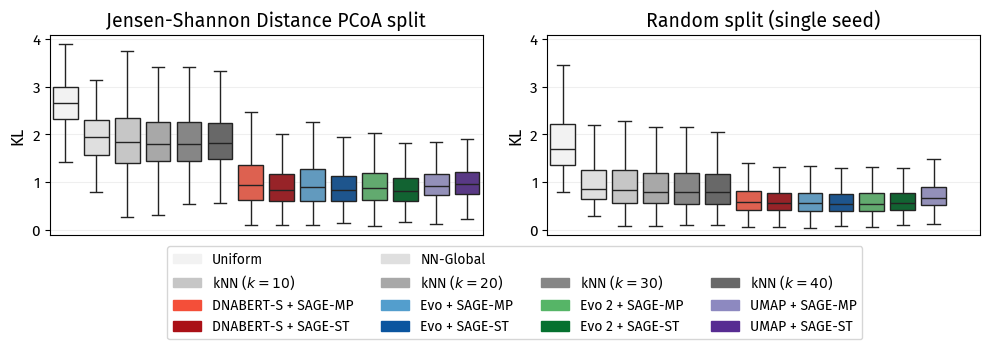

In [26]:
import matplotlib.pyplot as plt
from itertools import zip_longest


# ==================== data
baseline_methods_to_plot = [
    'uniform',
    'asv_nearest_neighbor',
    'asv_nearest_neighbor_KNN_10',
    'asv_nearest_neighbor_KNN_20',
    'asv_nearest_neighbor_KNN_30',
    'asv_nearest_neighbor_KNN_40',
]
torch_models_to_plot = [
    'dnabert-s__epc_pool_2_kl',
    'evo-1-8k-base_hyena5__epc_pool_2_kl',
    'evo2_7b_hyena10__epc_pool_2_kl',
    'umap_d100_s1000__epc_pool_2_kl',
    'dnabert-s__set_transformer_kl',
    'evo-1-8k-base_hyena5__set_transformer_kl',
    'evo2_7b_hyena10__set_transformer_kl',
    'umap_d100_s1000__set_transformer_kl',
]
pcoa_result_df = extract_concat_result(Path('results') / 'american_gut' / 'pcoa_split', baseline_methods_to_plot + torch_models_to_plot)
rng_result_dfs = {
    rng_seed: extract_concat_result(Path('results') / 'american_gut' / f'random_split_seed_{rng_seed}', baseline_methods_to_plot + torch_models_to_plot)
    for rng_seed in [100]
}

# ==================== plot
width = 12
height = 4
FONT_SIZE = 12
TITLE_FONT_SIZE = 14
LEGEND_FONT_SIZE = 10
xtick_angle = 50


fig = plt.figure(figsize=(width, height))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.05, wspace=0.15, width_ratios=[1, 1], height_ratios=[1, 0.5])

this_method_order = [
    'uniform', 'asv_nearest_neighbor', 'asv_nearest_neighbor_KNN_10', 'asv_nearest_neighbor_KNN_20', 'asv_nearest_neighbor_KNN_30', 'asv_nearest_neighbor_KNN_40',
    'dnabert-s__epc_pool_2_kl',
    'dnabert-s__set_transformer_kl',
    'evo-1-8k-base_hyena5__epc_pool_2_kl',
    'evo-1-8k-base_hyena5__set_transformer_kl',
    'evo2_7b_hyena10__epc_pool_2_kl',
    'evo2_7b_hyena10__set_transformer_kl',
    'umap_d100_s1000__epc_pool_2_kl',
    'umap_d100_s1000__set_transformer_kl',
]

baseline_colors = iter(sb.color_palette('Grays', 8))
name_mapping = {
    'uniform': 'Uniform',
    'asv_nearest_neighbor': 'NN-Global',
    'asv_nearest_neighbor_KNN_10': r'kNN ($k=10$)',
    'asv_nearest_neighbor_KNN_20': r'kNN ($k=20$)',
    'asv_nearest_neighbor_KNN_30': r'kNN ($k=30$)',
    'asv_nearest_neighbor_KNN_40': r'kNN ($k=40$)',
    'dnabert-s__epc_pool_2_kl': 'DNABERT-S + SAGE-MP',
    'evo-1-8k-base_hyena5__epc_pool_2_kl': 'Evo + SAGE-MP',
    'evo2_7b_hyena10__epc_pool_2_kl': 'Evo 2 + SAGE-MP',
    'umap_d100_s1000__epc_pool_2_kl': 'UMAP + SAGE-MP',
    'dnabert-s__set_transformer_kl': 'DNABERT-S + SAGE-ST',
    'evo-1-8k-base_hyena5__set_transformer_kl': 'Evo + SAGE-ST',
    'evo2_7b_hyena10__set_transformer_kl': 'Evo 2 + SAGE-ST',
    'umap_d100_s1000__set_transformer_kl': 'UMAP + SAGE-ST',
}
plot_palette = {
    'uniform': next(baseline_colors),
    'asv_nearest_neighbor': next(baseline_colors),
    'asv_nearest_neighbor_KNN_10': next(baseline_colors),
    'asv_nearest_neighbor_KNN_20': next(baseline_colors),
    'asv_nearest_neighbor_KNN_30': next(baseline_colors),
    'asv_nearest_neighbor_KNN_40': next(baseline_colors),
    'dnabert-s__epc_pool_2_kl': sb.color_palette('Reds', n_colors=6)[3],
    'evo-1-8k-base_hyena5__epc_pool_2_kl': sb.color_palette('Blues', n_colors=6)[3],
    'evo2_7b_hyena10__epc_pool_2_kl': sb.color_palette('Greens', n_colors=6)[3],
    'umap_d100_s1000__epc_pool_2_kl': sb.color_palette('Purples', n_colors=6)[3],
    'dnabert-s__set_transformer_kl': sb.color_palette('Reds', n_colors=6)[5],
    'evo-1-8k-base_hyena5__set_transformer_kl': sb.color_palette('Blues', n_colors=6)[5],
    'evo2_7b_hyena10__set_transformer_kl': sb.color_palette('Greens', n_colors=6)[5],
    'umap_d100_s1000__set_transformer_kl': sb.color_palette('Purples', n_colors=6)[5],
}

# this_method_order = [
#     'uniform', 'asv_nearest_neighbor', 'asv_nearest_neighbor_KNN_10', 'asv_nearest_neighbor_KNN_20', 'asv_nearest_neighbor_KNN_30', 'asv_nearest_neighbor_KNN_40',
#     'dnabert-s:epc_pool_kl', 'dnabert-s:epc_pool_1_kl', 'dnabert-s:epc_pool_2_kl', 'dnabert-s:epc_pool_3_kl',
#     'evo-1-8k-base_hyena5:epc_pool_kl', 'evo-1-8k-base_hyena5:epc_pool_1_kl', 'evo-1-8k-base_hyena5:epc_pool_2_kl', 'evo-1-8k-base_hyena5:epc_pool_3_kl',
#     'evo2_7b_hyena10:epc_pool_kl', 'evo2_7b_hyena10:epc_pool_1_kl', 'evo2_7b_hyena10:epc_pool_2_kl', 'evo2_7b_hyena10:epc_pool_3_kl',
#     'umap_d100_s1000:epc_pool_kl', 'umap_d100_s1000:epc_pool_1_kl', 'umap_d100_s1000:epc_pool_2_kl', 'umap_d100_s1000:epc_pool_3_kl',
# ]

legend_ax = fig.add_subplot(gs[-1, :])
legend_ax.axis("off")
cat1 = ['uniform', 'asv_nearest_neighbor']
cat2 = ['asv_nearest_neighbor_KNN_10', 'asv_nearest_neighbor_KNN_20', 'asv_nearest_neighbor_KNN_30', 'asv_nearest_neighbor_KNN_40']
cat3 = ['dnabert-s__epc_pool_2_kl', 'evo-1-8k-base_hyena5__epc_pool_2_kl', 'evo2_7b_hyena10__epc_pool_2_kl', 'umap_d100_s1000__epc_pool_2_kl']
cat4 = ['dnabert-s__set_transformer_kl', 'evo-1-8k-base_hyena5__set_transformer_kl', 'evo2_7b_hyena10__set_transformer_kl', 'umap_d100_s1000__set_transformer_kl']
columns = [cat1, cat2, cat3, cat4]
blank = mpatches.Patch(alpha=0, label=" ")

handles = [
    mpatches.Patch(color=plot_palette[m], label=name_mapping[m]) if m else blank
    for row in zip_longest(*columns) for m in row
]

legend_ax.legend(handles=handles, loc="center", frameon=True, title="Methods", ncol=4)



# handles = [
#     mpatches.Patch(color=plot_palette[method_label], label=name_mapping[method_label]) 
#     for method_label in this_method_order
# ]
# legend_ax.legend(handles=handles, loc="center", frameon=True, title="Methods", ncols=4)
# ## render_legend(this_method_order, plot_palette, name_mapping, legend_ax, font_size=LEGEND_FONT_SIZE)

_result = pcoa_result_df.loc[pcoa_result_df['Method'].isin(this_method_order)]
ax1 = fig.add_subplot(gs[0, 0])  # Spans rows 0-1, column 0
# ax2 = fig.add_subplot(gs[1, 0])  # Spans rows 0-1, column 1

boxplot_with_paired_significance(_result, hue='Method', y='KL_err', sample_col='Sample', ax=ax1, palette=plot_palette, hue_order=this_method_order, annot_pvals=False, fontsize=FONT_SIZE)
ax1.set_ylabel("KL", fontsize=FONT_SIZE, fontname="Fira Sans", fontweight='normal')
ax1.set_xlabel(None)
# ax1.set_xticks(range(len(this_method_order)), [name_mapping[_m] for _m in this_method_order], rotation=xtick_angle, ha='right', rotation_mode='anchor', fontname="Fira Sans", fontweight='normal')
ax1.set_xticks([])
ax1.set_title("Jensen-Shannon Distance PCoA split", fontname="Fira Sans", fontweight='normal', fontsize=TITLE_FONT_SIZE)

# boxplot_with_paired_significance(_result, hue='Method', y='RMSL_err', sample_col='Sample', ax=ax2, palette=plot_palette, hue_order=this_method_order, annot_pvals=False, fontsize=FONT_SIZE)
# ax2.set_ylabel("RMS-log", fontsize=FONT_SIZE, fontname="Fira Sans", fontweight='normal')
# ax2.set_xlabel(None)
# ax2.set_xticks(range(len(this_method_order)), [name_mapping[_m] for _m in this_method_order], rotation=xtick_angle, ha='right', rotation_mode='anchor', fontname="Fira Sans", fontweight='normal')
# ax2.set_xticks([])

rng_seed_to_show = 100
_result = rng_result_dfs[rng_seed_to_show]
_result = _result.loc[_result['Method'].isin(this_method_order)]
ax3 = fig.add_subplot(gs[0, 1])  # Spans rows 0-1, column 0
# ax4 = fig.add_subplot(gs[1, 1])  # Spans rows 0-1, column 1

boxplot_with_paired_significance(_result, hue='Method', y='KL_err', sample_col='Sample', ax=ax3, palette=plot_palette, hue_order=this_method_order, annot_pvals=False, fontsize=FONT_SIZE)
ax3.set_ylabel("KL", fontsize=FONT_SIZE, fontname="Fira Sans", fontweight='normal')
ax3.set_xlabel(None)
ax3.set_xticks([])
# ax3.set_xticks(range(len(this_method_order)), [name_mapping[_m] for _m in this_method_order], rotation=xtick_angle, ha='right', rotation_mode='anchor', fontname="Fira Sans", fontweight='normal')
ax3.set_title("Random split (single seed)", fontname="Fira Sans", fontweight='normal', fontsize=TITLE_FONT_SIZE)

# boxplot_with_paired_significance(_result, hue='Method', y='RMSL_err', sample_col='Sample', ax=ax4, palette=plot_palette, hue_order=this_method_order, annot_pvals=False, fontsize=FONT_SIZE)
# ax4.set_ylabel("RMS-log", fontsize=FONT_SIZE, fontname="Fira Sans", fontweight='normal')
# ax4.set_xlabel(None)
# ax4.set_xticks([])
# ax4.set_xticks(range(len(this_method_order)), [name_mapping[_m] for _m in this_method_order], rotation=xtick_angle, ha='right', rotation_mode='anchor', fontname="Fira Sans", fontweight='normal')

ax3.sharey(ax1)
# ax4.sharey(ax2)

from matplotlib.font_manager import FontProperties
custom_font = FontProperties(family='Fira Sans', weight='normal', size=11)
for ax in [ax1, ax3]:
    for label in ax.get_xticklabels():
        label.set_fontproperties(custom_font)
    for label in ax.get_yticklabels():
        label.set_fontproperties(custom_font)
    ax.grid(axis="y", linestyle="-", alpha=0.2)


legend_ax.get_legend().set_title("", prop=custom_font)
for text in legend_ax.get_legend().get_texts():
    text.set_fontsize(LEGEND_FONT_SIZE)
    text.set_fontfamily("Fira Sans")
    text.set_fontweight("normal")

plt.savefig("results/american_gut/asv_pcoa_and_rng_100_metrics.png", dpi=800, bbox_inches='tight', transparent=True)
plt.savefig("results/american_gut/asv_pcoa_and_rng_100_metrics.pdf", bbox_inches='tight', transparent=True)
print("done")

In [69]:
# ==================== render table
this_method_order = [
    'uniform', 'asv_nearest_neighbor', 'asv_nearest_neighbor_KNN_10', 'asv_nearest_neighbor_KNN_20', 'asv_nearest_neighbor_KNN_30', 'asv_nearest_neighbor_KNN_40',
    'dnabert-s__epc_pool_2_kl',
    'evo-1-8k-base_hyena5__epc_pool_2_kl',
    'evo2_7b_hyena10__epc_pool_2_kl',
    'umap_d100_s1000__epc_pool_2_kl',
    'dnabert-s__set_transformer_kl',
    'evo-1-8k-base_hyena5__set_transformer_kl',
    'evo2_7b_hyena10__set_transformer_kl',
    'umap_d100_s1000__set_transformer_kl',
]
latex_mapping = {
    'uniform': 'Uniform',
    'asv_nearest_neighbor': 'NN-Global', 
    'asv_nearest_neighbor_KNN_10': r'kNN $(k=10)$', 
    'asv_nearest_neighbor_KNN_20': r'kNN $(k=20)$', 
    'asv_nearest_neighbor_KNN_30': r'kNN $(k=30)$', 
    'asv_nearest_neighbor_KNN_40': r'kNN $(k=40)$', 
    'dnabert-s__epc_pool_2_kl': 'DNABERT-S + SAGE-MP',
    'evo-1-8k-base_hyena5__epc_pool_2_kl': 'Evo + SAGE-MP',
    'evo2_7b_hyena10__epc_pool_2_kl': 'Evo 2 + SAGE-MP',
    'umap_d100_s1000__epc_pool_2_kl': 'UMAP + SAGE-MP',
    'dnabert-s__set_transformer_kl': 'DNABERT-S + SAGE-ST',
    'evo-1-8k-base_hyena5__set_transformer_kl': 'Evo + SAGE-ST',
    'evo2_7b_hyena10__set_transformer_kl': 'Evo 2 + SAGE-ST',
    'umap_d100_s1000__set_transformer_kl': 'UMAP + SAGE-ST',
}

_sections = []
for rng_seed, rng_result_df in rng_result_dfs.items():
    agg = rng_result_df[['Method', 'KL_err']].groupby('Method').median().assign(Seed=rng_seed).reset_index()
    _sections.append(agg)
rng_agg_df = pd.concat(_sections, ignore_index=False)
del _sections
# display(pd.unique(rng_agg_df['Method']))  ## print all methods available

_x = rng_agg_df.loc[rng_agg_df['Method'].isin(this_method_order)]
_x = _x.assign(Method=_x['Method'].map(latex_mapping))[['Method', 'KL_err']].groupby("Method").median()
_y = pcoa_result_df.loc[pcoa_result_df['Method'].isin(this_method_order)].reset_index(drop=True)
_y = _y.assign(Method=_y['Method'].map(latex_mapping))[['Method', 'KL_err']].groupby("Method").median()

# Build the ordered list of display names from this_method_order
ordered_display = [latex_mapping[m] for m in this_method_order if m in latex_mapping]

# Then reindex after the merge
display_df = _x.merge(
    _y,
    left_index=True, right_index=True,
    how="outer",
    suffixes=['_rng', '_pcoa']
).reindex(ordered_display)

def fmt_cell(val, is_min):
    if is_min:
        return rf'\textbf{{{val:.4f}}}'
    return f'{val:.4f}'

min_pcoa = display_df['KL_err_pcoa'].min()
min_rng = display_df['KL_err_rng'].min()

display_df['JS-Maximizing Split (KL)'] = display_df.apply(
    lambda r: fmt_cell(r['KL_err_pcoa'], r['KL_err_pcoa'] == min_pcoa), axis=1
)
display_df['Random Split (KL)'] = display_df.apply(
    lambda r: fmt_cell(r['KL_err_rng'], r['KL_err_rng'] == min_rng), axis=1
)

display(display_df)

# Generate LaTeX with booktabs
latex = display_df[['JS-Maximizing Split (KL)', 'Random Split (KL)']].to_latex(
    index=True,
    escape=False,
    column_format="lcc",
    caption="Test set KL divergence evaluation of methods. \\textbf{JS-Maximizing Split}: median test KL for the $D_{JS}$ maximizing split. \\textbf{Random Split}: median-of-median test KL across ten random seeds. The minimal value in each column is highlighted in bold.",
    label="table:benchmark_asv",
    position="ht",
)

# Manually swap hlines for booktabs rules
lines = latex.splitlines()
result = []
for i, line in enumerate(lines):
    result.append(line)
    if line.strip().endswith(r"\\") and not any(
        marker in line for marker in [r"\toprule", r"\midrule", r"\bottomrule"]
    ):
        result.append(r"\midrule")
latex = "\n".join(result)
print(latex)

,KL_err_rng,KL_err_pcoa,JS-Maximizing Split (KL),Random Split (KL)
Method,,,,
Uniform,1.693820,2.656184,2.6562,1.6938
NN-Global,0.859321,1.933746,1.9337,0.8593
kNN $(k=10)$,0.828938,1.838225,1.8382,0.8289
kNN $(k=20)$,0.788583,1.798072,1.7981,0.7886
kNN $(k=30)$,0.785947,1.804362,1.8044,0.7859
kNN $(k=40)$,0.796117,1.809709,1.8097,0.7961
DNABERT-S + SAGE-MP,0.571604,0.937385,0.9374,0.5716
Evo + SAGE-MP,0.545106,0.897198,0.8972,0.5451
Evo 2 + SAGE-MP,0.535304,0.857789,0.8578,\textbf{0.5353}


\begin{table}[ht]
\caption{Test set KL divergence evaluation of methods. \textbf{JS-Maximizing Split}: median test KL for the $D_{JS}$ maximizing split. \textbf{Random Split}: median-of-median test KL across ten random seeds. The minimal value in each column is highlighted in bold.}
\label{table:benchmark_asv}
\begin{tabular}{lcc}
\toprule
 & JS-Maximizing Split (KL) & Random Split (KL) \\
\midrule
Method &  &  \\
\midrule
\midrule
Uniform & 2.6562 & 1.6938 \\
\midrule
NN-Global & 1.9337 & 0.8593 \\
\midrule
kNN $(k=10)$ & 1.8382 & 0.8289 \\
\midrule
kNN $(k=20)$ & 1.7981 & 0.7886 \\
\midrule
kNN $(k=30)$ & 1.8044 & 0.7859 \\
\midrule
kNN $(k=40)$ & 1.8097 & 0.7961 \\
\midrule
DNABERT-S + SAGE-MP & 0.9374 & 0.5716 \\
\midrule
Evo + SAGE-MP & 0.8972 & 0.5451 \\
\midrule
Evo 2 + SAGE-MP & 0.8578 & \textbf{0.5353} \\
\midrule
UMAP + SAGE-MP & 0.9528 & 0.6730 \\
\midrule
DNABERT-S + SAGE-ST & 0.8656 & 0.5671 \\
\midrule
Evo + SAGE-ST & 0.8245 & 0.5486 \\
\midrule
Evo 2 + SAGE-ST & \textbf{

In [70]:
print(pd.unique(pcoa_result_df['Method']))
print(this_method_order)

<ArrowStringArray>
[                                 'uniform',
                     'asv_nearest_neighbor',
              'asv_nearest_neighbor_KNN_10',
              'asv_nearest_neighbor_KNN_20',
              'asv_nearest_neighbor_KNN_30',
              'asv_nearest_neighbor_KNN_40',
                 'dnabert-s__epc_pool_2_kl',
      'evo-1-8k-base_hyena5__epc_pool_2_kl',
           'evo2_7b_hyena10__epc_pool_2_kl',
           'umap_d100_s1000__epc_pool_2_kl',
            'dnabert-s__set_transformer_kl',
 'evo-1-8k-base_hyena5__set_transformer_kl',
      'evo2_7b_hyena10__set_transformer_kl',
      'umap_d100_s1000__set_transformer_kl']
Length: 14, dtype: str
['uniform', 'asv_nearest_neighbor', 'asv_nearest_neighbor_KNN_10', 'asv_nearest_neighbor_KNN_20', 'asv_nearest_neighbor_KNN_30', 'asv_nearest_neighbor_KNN_40', 'dnabert-s__epc_pool_2_kl', 'evo-1-8k-base_hyena5__epc_pool_2_kl', 'evo2_7b_hyena10__epc_pool_2_kl', 'umap_d100_s1000__epc_pool_2_kl', 'dnabert-s__set_transformer_kl', 

In [73]:
from scipy import stats
from statsmodels.stats.multitest import multipletests
import numpy as np

# ==================== Statistical Testing

def get_paired_kl(result_df, method_a, method_b):
    """Extract paired KL values aligned by SampleId for two methods."""
    df_a = result_df.loc[result_df['Method'] == method_a, ['SampleId', 'KL_err']]
    df_b = result_df.loc[result_df['Method'] == method_b, ['SampleId', 'KL_err']]
    merged = df_a.merge(df_b, on='SampleId', suffixes=('_a', '_b'))
    return merged['KL_err_a'].values, merged['KL_err_b'].values

def run_pairwise_wilcoxon(result_df, method_order, latex_mapping):
    display_names = [latex_mapping[m] for m in method_order if m in latex_mapping]
    n = len(display_names)
    pairs = [(i, j) for i in range(n) for j in range(i+1, n)]

    pvals_raw = []
    for i, j in pairs:
        m_a = method_order[i]
        m_b = method_order[j]
        a, b = get_paired_kl(result_df, m_a, m_b)
        _, p = stats.wilcoxon(a, b, alternative='two-sided')
        pvals_raw.append(p)

    _, pvals_corrected, _, _ = multipletests(pvals_raw, method='fdr_bh')

    pval_df = pd.DataFrame(np.nan, index=display_names, columns=display_names)
    for (i, j), p in zip(pairs, pvals_corrected):
        pval_df.iloc[i, j] = p
        pval_df.iloc[j, i] = p

    return pval_df

# JS-maximizing split: full sample-level KL
pval_matrix_pcoa = run_pairwise_wilcoxon(pcoa_result_df, this_method_order, latex_mapping)

# Random split: use first seed only
first_seed = list(rng_result_dfs.keys())[0]
pval_matrix_rng = run_pairwise_wilcoxon(rng_result_dfs[first_seed], this_method_order, latex_mapping)

# ==================== Render as LaTeX 2D grids

def pval_to_latex_cell(p, threshold=0.05):
    if np.isnan(p):
        return r'--'
    elif p < threshold:
        return rf'\textbf{{{p:.3f}}}$^*$'
    else:
        return rf'{{\color{{gray}}{p:.3f}}}'

def render_pval_table(pval_df, caption, label):
    methods = pval_df.index.tolist()
    n = len(methods)

    col_format = 'l' + 'c' * n
    header = ' & '.join([''] + methods) + r' \\'

    rows = []
    for i in range(n):
        cells = [methods[i]]
        for j in range(n):
            if i == j:
                cells.append(r'--')
            else:
                cells.append(pval_to_latex_cell(pval_df.iloc[i, j]))
        rows.append(' & '.join(cells) + r' \\')

    grid_table = '\n'.join([
        rf'\begin{{table}}[ht]',
        r'\centering',
        r'\resizebox{\textwidth}{!}{',
        rf'\begin{{tabular}}{{{col_format}}}',
        r'\toprule',
        header,
        r'\midrule',
        '\n'.join(rows),
        r'\bottomrule',
        r'\end{tabular}',
        r'}',
        r'\vspace{4pt}',
        rf'\caption{{{caption}}}',
        rf'\label{{{label}}}',
        r'\end{table}',
    ])

    return grid_table

grid_rng = render_pval_table(
    pval_matrix_rng,
    caption=r'Pairwise Wilcoxon signed-rank p-values (BH-corrected) on per-sample KL, random split (single seed). Bold$^*$: $p < 0.05$.',
    label='table:pval_rng'
)

grid_pcoa = render_pval_table(
    pval_matrix_pcoa,
    caption=r'Pairwise Wilcoxon signed-rank p-values (BH-corrected) on per-sample KL, JS-maximizing split. Bold$^*$: $p < 0.05$.',
    label='table:pval_pcoa'
)

print("% ===== Random Split p-value grid =====")
print(grid_rng)
print()
print("% ===== JS-Maximizing Split p-value grid =====")
print(grid_pcoa)

% ===== Random Split p-value grid =====
\begin{table}[ht]
\centering
\resizebox{\textwidth}{!}{
\begin{tabular}{lcccccccccccccc}
\toprule
 & Uniform & NN-Global & kNN $(k=10)$ & kNN $(k=20)$ & kNN $(k=30)$ & kNN $(k=40)$ & DNABERT-S + SAGE-MP & Evo + SAGE-MP & Evo 2 + SAGE-MP & UMAP + SAGE-MP & DNABERT-S + SAGE-ST & Evo + SAGE-ST & Evo 2 + SAGE-ST & UMAP + SAGE-ST \\
\midrule
Uniform & -- & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ \\
NN-Global & \textbf{0.000}$^*$ & -- & \textbf{0.048}$^*$ & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ \\
kNN $(k=10)$ & \textbf{0.000}$^*$ & \text

## Extra figures

Loading: results/american_gut/pcoa_split/umap_d20_s1000__epc_pool_kl.tsv
Loading: results/american_gut/pcoa_split/umap_d40_s1000__epc_pool_kl.tsv
Loading: results/american_gut/pcoa_split/umap_d60_s1000__epc_pool_kl.tsv
Loading: results/american_gut/pcoa_split/umap_d80_s1000__epc_pool_kl.tsv
Loading: results/american_gut/pcoa_split/umap_d100_s1000__epc_pool_kl.tsv
Loading: results/american_gut/pcoa_split/umap_d20_s1000__epc_pool_1_kl.tsv
Loading: results/american_gut/pcoa_split/umap_d40_s1000__epc_pool_1_kl.tsv
Loading: results/american_gut/pcoa_split/umap_d60_s1000__epc_pool_1_kl.tsv
Loading: results/american_gut/pcoa_split/umap_d80_s1000__epc_pool_1_kl.tsv
Loading: results/american_gut/pcoa_split/umap_d100_s1000__epc_pool_1_kl.tsv
Loading: results/american_gut/pcoa_split/umap_d20_s1000__epc_pool_2_kl.tsv
Loading: results/american_gut/pcoa_split/umap_d40_s1000__epc_pool_2_kl.tsv
Loading: results/american_gut/pcoa_split/umap_d60_s1000__epc_pool_2_kl.tsv
Loading: results/american_gut/pco

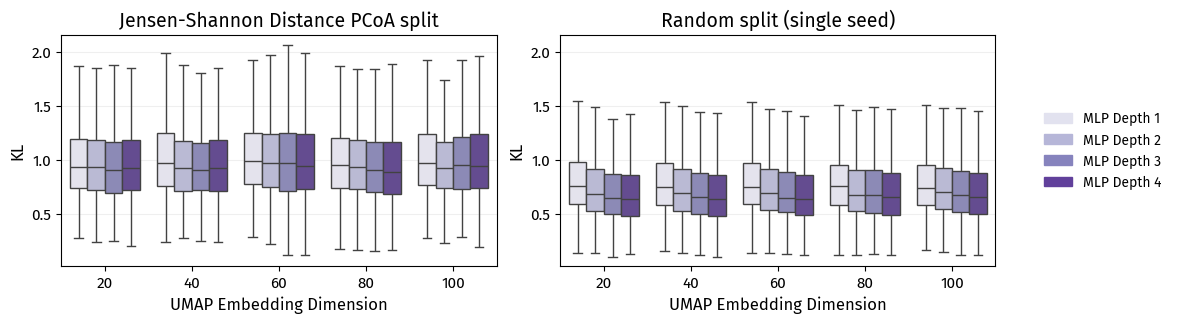

In [36]:
import matplotlib.pyplot as plt

# ==================== data
torch_models_to_plot = [
    'umap_d20_s1000__epc_pool_kl',
    'umap_d40_s1000__epc_pool_kl',
    'umap_d60_s1000__epc_pool_kl',
    'umap_d80_s1000__epc_pool_kl',
    'umap_d100_s1000__epc_pool_kl',
    'umap_d20_s1000__epc_pool_1_kl',
    'umap_d40_s1000__epc_pool_1_kl',
    'umap_d60_s1000__epc_pool_1_kl',
    'umap_d80_s1000__epc_pool_1_kl',
    'umap_d100_s1000__epc_pool_1_kl',
    'umap_d20_s1000__epc_pool_2_kl',
    'umap_d40_s1000__epc_pool_2_kl',
    'umap_d60_s1000__epc_pool_2_kl',
    'umap_d80_s1000__epc_pool_2_kl',
    'umap_d100_s1000__epc_pool_2_kl',
    'umap_d20_s1000__epc_pool_3_kl',
    'umap_d40_s1000__epc_pool_3_kl',
    'umap_d60_s1000__epc_pool_3_kl',
    'umap_d80_s1000__epc_pool_3_kl',
    'umap_d100_s1000__epc_pool_3_kl',
]
pcoa_result_df = extract_concat_result(Path('results') / 'american_gut' / 'pcoa_split', torch_models_to_plot)
rng_result_dfs = {
    rng_seed: extract_concat_result(Path('results') / 'american_gut' / f'random_split_seed_{rng_seed}', torch_models_to_plot)
    for rng_seed in [100]
}


# ==================== plot
width = 14
height = 3
FONT_SIZE = 12
TITLE_FONT_SIZE = 14
LEGEND_FONT_SIZE = 10
xtick_angle = 50


fig = plt.figure(figsize=(width, height))
gs = gridspec.GridSpec(1, 3, figure=fig, hspace=0.1, wspace=0.2, width_ratios=[1, 1, 0.2],)

this_method_order = [
    'umap_d20_s1000__epc_pool_kl', 'umap_d20_s1000__epc_pool_1_kl', 'umap_d20_s1000__epc_pool_2_kl', 'umap_d20_s1000__epc_pool_3_kl',
    'umap_d40_s1000__epc_pool_kl', 'umap_d40_s1000__epc_pool_1_kl', 'umap_d40_s1000__epc_pool_2_kl', 'umap_d40_s1000__epc_pool_3_kl',
    'umap_d60_s1000__epc_pool_kl', 'umap_d60_s1000__epc_pool_1_kl', 'umap_d60_s1000__epc_pool_2_kl', 'umap_d60_s1000__epc_pool_3_kl',
    'umap_d80_s1000__epc_pool_kl', 'umap_d80_s1000__epc_pool_1_kl', 'umap_d80_s1000__epc_pool_2_kl', 'umap_d80_s1000__epc_pool_3_kl',
    'umap_d100_s1000__epc_pool_kl', 'umap_d100_s1000__epc_pool_1_kl', 'umap_d100_s1000__epc_pool_2_kl', 'umap_d100_s1000__epc_pool_3_kl',
]

_result = pcoa_result_df.loc[pcoa_result_df['Method'].isin(this_method_order)]
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])


def parse_embed_dim(method_name: str) -> int:
    tokens = method_name.split("_")
    d_str = tokens[1]
    assert d_str.startswith("d")
    return int(d_str[1:])

def parse_mlp_dim(method_name: str) -> int:
    tokens = method_name.split("__")
    pred_model = tokens[1]
    if pred_model == "epc_pool_kl":
        return 1
    elif pred_model == "epc_pool_1_kl":
        return 2
    elif pred_model == "epc_pool_2_kl":
        return 3
    elif pred_model == "epc_pool_3_kl":
        return 4
        
colors = sb.color_palette("Purples", 4)
mlp_colors = {
    1: colors[0],
    2: colors[1],
    3: colors[2],
    4: colors[3],
}

_result = _result.assign(EmbedDim=_result['Method'].map(parse_embed_dim), MLPDim=_result['Method'].map(parse_mlp_dim))
sb.boxplot(
    _result,
    x='EmbedDim', y='KL_err', hue='MLPDim', palette=mlp_colors,
    ax=ax1,
    legend=False,
    showfliers=False,
)
ax1.set_xlabel("UMAP Embedding Dimension", fontsize=FONT_SIZE, fontname="Fira Sans", fontweight='normal')
ax1.set_ylabel("KL", fontsize=FONT_SIZE, fontname="Fira Sans", fontweight='normal')
ax1.set_title("Jensen-Shannon Distance PCoA split", fontname="Fira Sans", fontweight='normal', fontsize=TITLE_FONT_SIZE)


rng_seed_to_show = 100
_result = rng_result_dfs[rng_seed_to_show]
_result = _result.loc[_result['Method'].isin(this_method_order)]
_result = _result.assign(EmbedDim=_result['Method'].map(parse_embed_dim), MLPDim=_result['Method'].map(parse_mlp_dim))
sb.boxplot(
    _result,
    x='EmbedDim', y='KL_err', hue='MLPDim', palette=mlp_colors,
    ax=ax2,
    legend=False,
    showfliers=False,
)
ax2.set_xlabel("UMAP Embedding Dimension", fontsize=FONT_SIZE, fontname="Fira Sans", fontweight='normal')
ax2.set_ylabel("KL", fontsize=FONT_SIZE, fontname="Fira Sans", fontweight='normal')
ax2.sharey(ax1)
ax2.set_title("Random split (single seed)", fontname="Fira Sans", fontweight='normal', fontsize=TITLE_FONT_SIZE)


legend_ax = fig.add_subplot(gs[0, -1])
legend_ax.axis("off")
handles = [mpatches.Patch(color=mlp_colors[mlp_dim], label=f'MLP Depth {mlp_dim}') for mlp_dim in [1, 2, 3, 4]]
legend_ax.legend(
    handles=handles, loc="center", 
    frameon=False, title="Methods", ncols=1,
)

from matplotlib.font_manager import FontProperties
custom_font = FontProperties(family='Fira Sans', weight='normal', size=11)
for ax in [ax1, ax2]:
    ax.grid(axis="y", linestyle="-", alpha=0.2)
    for label in ax.get_xticklabels():
        label.set_fontproperties(custom_font)
    for label in ax.get_yticklabels():
        label.set_fontproperties(custom_font)


legend_ax.get_legend().set_title("", prop=custom_font)
for text in legend_ax.get_legend().get_texts():
    text.set_fontsize(LEGEND_FONT_SIZE)
    text.set_fontfamily("Fira Sans")
    text.set_fontweight("normal")

plt.savefig("results/american_gut/asv_metrics_umap_range.pdf", bbox_inches='tight', transparent=True)
plt.savefig("results/american_gut/asv_metrics_umap_range.png", dpi=800, bbox_inches='tight', transparent=True)
print("done")

Loading: results/american_gut/pcoa_split/dnabert-s__epc_pool_kl.tsv
Loading: results/american_gut/pcoa_split/dnabert-s__epc_pool_1_kl.tsv
Loading: results/american_gut/pcoa_split/dnabert-s__epc_pool_2_kl.tsv
Loading: results/american_gut/pcoa_split/dnabert-s__epc_pool_3_kl.tsv
Loading: results/american_gut/pcoa_split/evo-1-8k-base_hyena5__epc_pool_kl.tsv
Loading: results/american_gut/pcoa_split/evo-1-8k-base_hyena5__epc_pool_1_kl.tsv
Loading: results/american_gut/pcoa_split/evo-1-8k-base_hyena5__epc_pool_2_kl.tsv
Loading: results/american_gut/pcoa_split/evo-1-8k-base_hyena5__epc_pool_3_kl.tsv
Loading: results/american_gut/pcoa_split/evo2_7b_hyena10__epc_pool_kl.tsv
Loading: results/american_gut/pcoa_split/evo2_7b_hyena10__epc_pool_1_kl.tsv
Loading: results/american_gut/pcoa_split/evo2_7b_hyena10__epc_pool_2_kl.tsv
Loading: results/american_gut/pcoa_split/evo2_7b_hyena10__epc_pool_3_kl.tsv
Loading: results/american_gut/random_split_seed_100/dnabert-s__epc_pool_kl.tsv
Loading: results/am

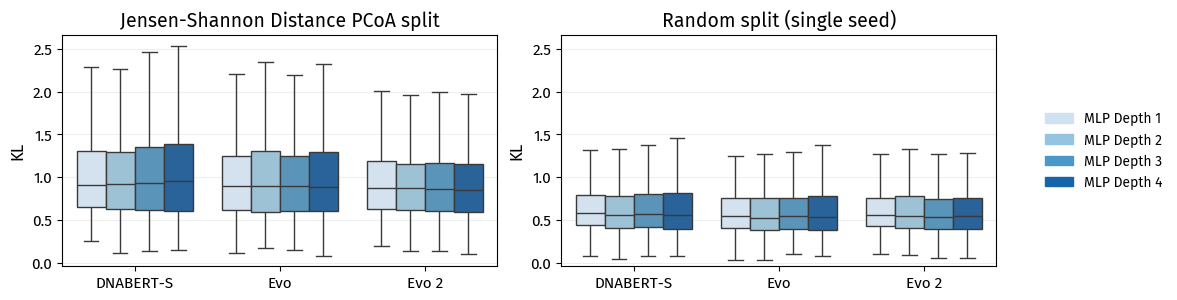

In [43]:
import matplotlib.pyplot as plt


# ==================== data
torch_models_to_plot = [
    'dnabert-s__epc_pool_kl',
    'dnabert-s__epc_pool_1_kl',
    'dnabert-s__epc_pool_2_kl',
    'dnabert-s__epc_pool_3_kl',
    
    'evo-1-8k-base_hyena5__epc_pool_kl',
    'evo-1-8k-base_hyena5__epc_pool_1_kl',
    'evo-1-8k-base_hyena5__epc_pool_2_kl',
    'evo-1-8k-base_hyena5__epc_pool_3_kl',
    
    'evo2_7b_hyena10__epc_pool_kl',
    'evo2_7b_hyena10__epc_pool_1_kl',
    'evo2_7b_hyena10__epc_pool_2_kl',
    'evo2_7b_hyena10__epc_pool_3_kl',
]
pcoa_result_df = extract_concat_result(Path('results') / 'american_gut' / 'pcoa_split', torch_models_to_plot)
rng_result_dfs = {
    rng_seed: extract_concat_result(Path('results') / 'american_gut' / f'random_split_seed_{rng_seed}', torch_models_to_plot)
    for rng_seed in [100]
}


# ==================== plot
width = 14
height = 3
FONT_SIZE = 12
TITLE_FONT_SIZE = 14
LEGEND_FONT_SIZE = 10
xtick_angle = 50

EMBED_DISPLAY_NAMES = {
    'dnabert-s': "DNABERT-S",
    'evo-1-8k-base_hyena5': "Evo",
    'evo2_7b_hyena10': "Evo 2",
}

fig = plt.figure(figsize=(width, height))
gs = gridspec.GridSpec(1, 3, figure=fig, hspace=0.1, wspace=0.2, width_ratios=[1, 1, 0.2],)

this_method_order = torch_models_to_plot

_result = pcoa_result_df.loc[pcoa_result_df['Method'].isin(this_method_order)]
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])


def parse_embed_type(method_name: str) -> str:
    tokens = method_name.split("__")
    return EMBED_DISPLAY_NAMES[tokens[0]]

def parse_mlp_dim(method_name: str) -> int:
    tokens = method_name.split("__")
    pred_model = tokens[1]
    if pred_model == "epc_pool_kl":
        return 1
    elif pred_model == "epc_pool_1_kl":
        return 2
    elif pred_model == "epc_pool_2_kl":
        return 3
    elif pred_model == "epc_pool_3_kl":
        return 4
        
colors = sb.color_palette("Blues", 4)
mlp_colors = {
    1: colors[0],
    2: colors[1],
    3: colors[2],
    4: colors[3],
}

_result = _result.assign(EmbedType=_result['Method'].map(parse_embed_type), MLPDim=_result['Method'].map(parse_mlp_dim))
sb.boxplot(
    _result,
    x='EmbedType', y='KL_err', hue='MLPDim', palette=mlp_colors,
    ax=ax1,
    legend=False,
    showfliers=False,
)
ax1.set_xlabel(None, fontsize=FONT_SIZE, fontname="Fira Sans", fontweight='normal')
ax1.set_ylabel("KL", fontsize=FONT_SIZE, fontname="Fira Sans", fontweight='normal')
ax1.set_title("Jensen-Shannon Distance PCoA split", fontname="Fira Sans", fontweight='normal', fontsize=TITLE_FONT_SIZE)


rng_seed_to_show = 100
_result = rng_result_dfs[rng_seed_to_show]
_result = _result.loc[_result['Method'].isin(this_method_order)]
_result = _result.assign(EmbedType=_result['Method'].map(parse_embed_type), MLPDim=_result['Method'].map(parse_mlp_dim))
sb.boxplot(
    _result,
    x='EmbedType', y='KL_err', hue='MLPDim', palette=mlp_colors,
    ax=ax2,
    legend=False,
    showfliers=False,
)
ax2.set_xlabel(None, fontsize=FONT_SIZE, fontname="Fira Sans", fontweight='normal')
ax2.set_ylabel("KL", fontsize=FONT_SIZE, fontname="Fira Sans", fontweight='normal')
ax2.sharey(ax1)
ax2.set_title("Random split (single seed)", fontname="Fira Sans", fontweight='normal', fontsize=TITLE_FONT_SIZE)

legend_ax = fig.add_subplot(gs[0, -1])
legend_ax.axis("off")
handles = [mpatches.Patch(color=mlp_colors[mlp_dim], label=f'MLP Depth {mlp_dim}') for mlp_dim in [1, 2, 3, 4]]
legend_ax.legend(
    handles=handles, loc="center", 
    frameon=False, title="Methods", ncols=1,
)

from matplotlib.font_manager import FontProperties
custom_font = FontProperties(family='Fira Sans', weight='normal', size=11)
for ax in [ax1, ax2]:
    ax.grid(axis="y", linestyle="-", alpha=0.2)
    for label in ax.get_xticklabels():
        label.set_fontproperties(custom_font)
    for label in ax.get_yticklabels():
        label.set_fontproperties(custom_font)


legend_ax.get_legend().set_title("", prop=custom_font)
for text in legend_ax.get_legend().get_texts():
    text.set_fontsize(LEGEND_FONT_SIZE)
    text.set_fontfamily("Fira Sans")
    text.set_fontweight("normal")

plt.savefig("results/american_gut/asv_metrics_mlp_layer_comparison.pdf", bbox_inches='tight', transparent=True)
plt.savefig("results/american_gut/asv_metrics_mlp_layer_comparison.png", dpi=800, bbox_inches='tight', transparent=True)
print("done")

## Ablation results

In [82]:
# ==================== dataframes
def extract_ablation_concat_result(results_dir: Path, method_names: List):
    eval_result_dfs = []
    
    # torch models
    for method_name in method_names:
        tsv_path = results_dir / f"{method_name}.tsv"
        if not tsv_path.exists():
            print("Torch result tsv does not exist: {}".format(tsv_path))
            continue
        eval_result_dfs.append(
            pd.read_csv(tsv_path, sep='\t').assign(
                Method=method_name, Ablated=False
            )
        )


        ablation_tsv_path = results_dir / f"{method_name}__ABLATED.tsv"
        if not ablation_tsv_path.exists():
            print("Ablated torch result tsv does not exist: {}".format(ablation_tsv_path))
            continue
        eval_result_dfs.append(
            pd.read_csv(ablation_tsv_path, sep='\t').assign(
                Method=method_name, Ablated=True
            )
        )
    
    eval_result_df = pd.concat(eval_result_dfs, ignore_index=True)
    return eval_result_df

In [77]:
# # embed_models_to_plot = ['dnabert-s', 'evo-1-8k-base_hyena5', 'evo2_7b_hyena10']
# # embed_models_to_plot += ['umap_d20_s1000', 'umap_d40_s1000', 'umap_d60_s1000', 'umap_d80_s1000', 'umap_d100_s1000']
# # pred_models_to_plot = ['epc_pool_kl', 'epc_pool_1_kl', 'epc_pool_2_kl', 'epc_pool_3_kl']
# # baseline_methods = ['uniform', 'asv_nearest_neighbor', 'asv_nearest_neighbor_withinproj']
# # baseline_methods += [f'asv_nearest_neighbor_KNN_{i}' for i in (10, 20, 30, 40)]

# embed_models_to_plot = [
#     TorchInferenceCategory('dnabert-s', 'DNABERT-S', 'DNABERT-S'), 
#     TorchInferenceCategory('evo-1-8k-base_hyena5', 'Evo 1', 'Evo 1'), 
#     TorchInferenceCategory('evo2_7b_hyena10', 'Evo 2', 'Evo 2'),
#     TorchInferenceCategory('umap_d100_s1000', 'UMAP (d=100)', 'UMAP ($d=100$)'),
# ]
# pred_models_to_plot = [
#     PredCategory('epc_pool_3_kl','MLP Depth 4', 'MLP Depth 4'),
#     # PredCategory('set_transformer_kl', 'Set-Transformer', 'Set-Transformer'),
# ]
# pcoa_ablation_result_df = extract_ablation_concat_result(Path('results') / 'american_gut' / 'pcoa_split', embed_models_to_plot, pred_models_to_plot)


# embed_models_to_plot = [
#     TorchInferenceCategory('dnabert-s', 'DNABERT-S', 'DNABERT-S'), 
#     TorchInferenceCategory('evo-1-8k-base_hyena5', 'Evo 1', 'Evo 1'), 
#     TorchInferenceCategory('evo2_7b_hyena10', 'Evo 2', 'Evo 2'),
#     TorchInferenceCategory('umap_d100_s1000', 'UMAP (d=100)', 'UMAP ($d=100$)'),
# ]
# pred_models_to_plot = [
#     PredCategory('epc_pool_3_kl','MLP Depth 4', 'MLP Depth 4'),
#     PredCategory('epc_nopool_3_kl','MLP Depth 4', 'MLP Depth 4'),
# ]
# pool_vs_nopool_df = extract_concat_result(Path('results') / 'american_gut' / 'pcoa_split', [], embed_models_to_plot, pred_models_to_plot)
# # rng_ablation_result_dfs = {
# #     rng_seed: extract_ablation_concat_result(Path('results') / 'american_gut' / f'random_split_seed_{rng_seed}', embed_models_to_plot, pred_models_to_plot)
# #     for rng_seed in [100, 101, 102, 103, 104, 105, 106, 107, 108, 109]
# # }

In [100]:
def pool_vs_nopool_boxplot(df, ax, font_size, embed_palette):
    ablation_df = pd.concat([
        df.loc[df['Method'].str.contains("_pool_")].assign(Pooled=True),
        df.loc[df['Method'].str.contains("_nopool_")].assign(Pooled=False),
    ], ignore_index=True)
    ablation_df['Embedding'] = ablation_df['Method'].str.split("__").str[0]
    display(ablation_df)

    EMBEDDING_NAMES = ['dnabert-s', 'evo-1-8k-base_hyena5', 'evo2_7b_hyena10', 'umap_d100_s1000']
    HATCH_PATTERNS = {
        True:      "",
        False:   "///",
    }
    
    n_methods = len(EMBEDDING_NAMES)
    group_width  = 0.8
    box_width    = group_width / 2
    offsets      = np.linspace(
        -group_width / 2 + box_width / 2,
         group_width / 2 - box_width / 2,
        len([True, False])
    )

    for i, embed_name in enumerate(EMBEDDING_NAMES):
        color = embed_palette[embed_name]
        for j, is_pooled in enumerate([True, False]):
            subset = ablation_df[(ablation_df["Pooled"] == is_pooled) & (ablation_df["Embedding"] == embed_name)]["KL_err"]
            if subset.empty:
                continue
    
            pos    = i + offsets[j]
            hatch  = HATCH_PATTERNS[is_pooled]
    
            bp = ax.boxplot(
                subset,
                positions=[pos],
                widths=box_width,
                patch_artist=True,
                manage_ticks=False,
                showfliers=False,
                medianprops=dict(color="black", linewidth=1),
                # whiskerprops=dict(color=color, linewidth=1),
                # capprops=dict(color=color, linewidth=1),
                # boxprops=dict(linewidth=1),
            )
    
            for patch in bp["boxes"]:
                patch.set_facecolor(color)
                patch.set_alpha(0.85)
                patch.set_hatch(hatch)
                # patch.set_edge
    
    # Legend for gene sets (hatch)
    ablation_handles = [
        mpatches.Patch(facecolor="white", edgecolor="black", hatch=HATCH_PATTERNS[True], label="Pooling"),
        mpatches.Patch(facecolor="white", edgecolor="black", hatch=HATCH_PATTERNS[False], label="No Pooling")
    ]
    leg2 = ax.legend(
        handles=ablation_handles, title=None,
        loc="upper left", bbox_to_anchor=(0, 1),
        prop={'family': 'Fira Sans', 'weight': 'normal'},
        fontsize=LEGEND_FONT_SIZE, title_fontsize=LEGEND_FONT_SIZE+1, frameon=True)
    ax.add_artist(leg2)

In [79]:
import matplotlib.pyplot as plt


def ablation_boxplot(df, ax, method_order: List[str], method_names: Dict[str, str], method_palette: Dict[str, np.ndarray], y_col: str):
    HATCH_PATTERNS = {
        False:  "",
        True:   "///",
    }

    n_methods = len(method_names)
    group_width  = 0.8
    box_width    = group_width / 2
    offsets      = np.linspace(
        -group_width / 2 + box_width / 2,
         group_width / 2 - box_width / 2,
        len([True, False])
    )

    for i, method in enumerate(method_order):
        color = method_palette[method]
        for j, is_ablated in enumerate([False, True]):
            subset = df[(df["Ablated"] == is_ablated) & (df["Method"] == method)]["KL_err"]
            if subset.empty:
                continue
    
            pos    = i + offsets[j]
            hatch  = HATCH_PATTERNS[is_ablated]
    
            bp = ax.boxplot(
                subset,
                positions=[pos],
                widths=box_width,
                patch_artist=True,
                manage_ticks=False,
                showfliers=False,
                medianprops=dict(color="black", linewidth=1),
                # whiskerprops=dict(color=color, linewidth=1),
                # capprops=dict(color=color, linewidth=1),
                # boxprops=dict(linewidth=1),
            )
    
            for patch in bp["boxes"]:
                patch.set_facecolor(color)
                patch.set_alpha(0.85)
                patch.set_hatch(hatch)
                # patch.set_edge
    
    # Legend for gene sets (hatch)
    ablation_handles = [
        mpatches.Patch(facecolor="white", edgecolor="black", hatch=HATCH_PATTERNS[False], label="Full Model"),
        mpatches.Patch(facecolor="white", edgecolor="black", hatch=HATCH_PATTERNS[True], label="Ablated Model")
    ]
    leg2 = ax.legend(
        handles=ablation_handles, title=None,
        loc="upper left", bbox_to_anchor=(0, 1),
        prop={'family': 'Fira Sans', 'weight': 'normal'},
        fontsize=LEGEND_FONT_SIZE, title_fontsize=LEGEND_FONT_SIZE+1, frameon=True)
    ax.add_artist(leg2)

<ArrowStringArray>
[           'dnabert-s__epc_pool_3_kl', 'evo-1-8k-base_hyena5__epc_pool_3_kl',
      'evo2_7b_hyena10__epc_pool_3_kl',      'umap_d100_s1000__epc_pool_3_kl']
Length: 4, dtype: str

Loading: results/american_gut/pcoa_split/dnabert-s__epc_pool_3_kl.tsv
Loading: results/american_gut/pcoa_split/dnabert-s__epc_nopool_3_kl.tsv
Loading: results/american_gut/pcoa_split/evo-1-8k-base_hyena5__epc_pool_3_kl.tsv
Loading: results/american_gut/pcoa_split/evo-1-8k-base_hyena5__epc_nopool_3_kl.tsv
Loading: results/american_gut/pcoa_split/evo2_7b_hyena10__epc_pool_3_kl.tsv
Loading: results/american_gut/pcoa_split/evo2_7b_hyena10__epc_nopool_3_kl.tsv
Loading: results/american_gut/pcoa_split/umap_d100_s1000__epc_pool_3_kl.tsv
Loading: results/american_gut/pcoa_split/umap_d100_s1000__epc_nopool_3_kl.tsv


,SampleId,KL_err,RMSL_err,SpearmanCorr,BrayCurtis,RootJensenShannon,NumSGB,Method,NumParameters,Pooled,Embedding
0,ERS6283731,1.461187,0.862258,0.693502,0.677787,0.553229,98,dnabert-s__epc_pool_3_kl,NaN,True,dnabert-s
1,ERS6283728,1.133975,0.788011,0.678040,0.617199,0.494166,99,dnabert-s__epc_pool_3_kl,NaN,True,dnabert-s
2,ERS6283726,0.532874,0.705727,0.687471,0.429899,0.387700,109,dnabert-s__epc_pool_3_kl,NaN,True,dnabert-s
3,ERS6283724,1.445107,0.895545,0.581091,0.683312,0.558024,121,dnabert-s__epc_pool_3_kl,NaN,True,dnabert-s
4,ERS6283723,0.974842,0.804163,0.656543,0.582944,0.494696,107,dnabert-s__epc_pool_3_kl,NaN,True,dnabert-s
...,...,...,...,...,...,...,...,...,...,...,...
6163,ERS4851158,1.098851,0.688634,0.354333,0.606937,0.499607,142,umap_d100_s1000__epc_nopool_3_kl,36769.0,False,umap_d100_s1000
6164,ERS7061585,1.450540,0.810927,0.670177,0.658869,0.541464,126,umap_d100_s1000__epc_nopool_3_kl,36769.0,False,umap_d100_s1000
6165,ERS7061584,1.232919,0.726766,0.682403,0.597813,0.494841,136,umap_d100_s1000__epc_nopool_3_kl,36769.0,False,umap_d100_s1000
6166,ERS7061496,1.458156,1.044269,0.323230,0.722266,0.575335,95,umap_d100_s1000__epc_nopool_3_kl,36769.0,False,umap_d100_s1000


done


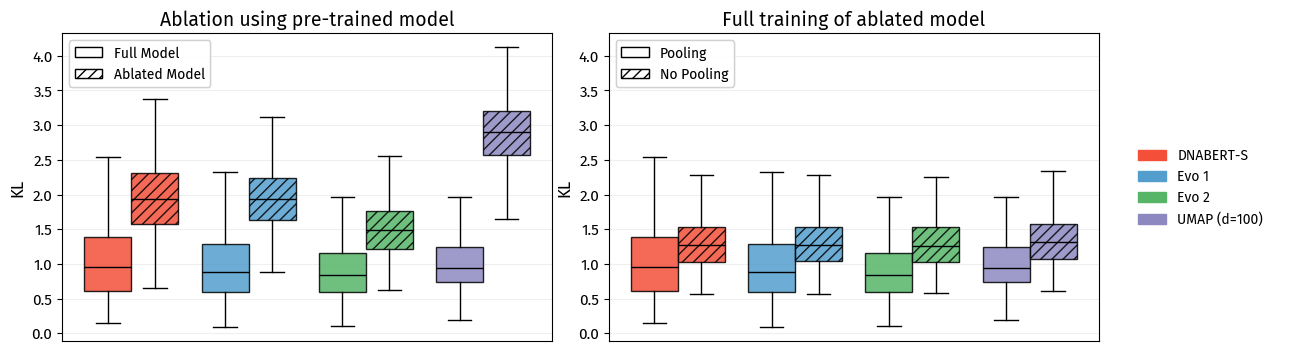

In [106]:
# ==================== data
torch_models_to_plot = [
    'dnabert-s__epc_pool_3_kl',
    'evo-1-8k-base_hyena5__epc_pool_3_kl',
    'evo2_7b_hyena10__epc_pool_3_kl',
    'umap_d100_s1000__epc_pool_3_kl',
]
pcoa_ablation_result_df = extract_ablation_concat_result(Path('results') / 'american_gut' / 'pcoa_split', torch_models_to_plot)


# ==================== plot
width = 16
height = 4
FONT_SIZE = 12
TITLE_FONT_SIZE = 14
LEGEND_FONT_SIZE = 10
xtick_angle = 30


fig = plt.figure(figsize=(width, height))
gs = gridspec.GridSpec(1, 3, figure=fig, hspace=0.05, wspace=0.15, width_ratios=[1, 1, 0.3], height_ratios=[1])


ax1 = fig.add_subplot(gs[0, 0])  # Spans rows 0-1, column 0
ax2 = fig.add_subplot(gs[0, 1])  # Spans rows 0-1, column 1

display(pd.unique(_result['Method']))
this_method_order = torch_models_to_plot
plot_palette = {
    'dnabert-s__epc_pool_3_kl': sb.color_palette('Reds', n_colors=6)[3],
    'evo-1-8k-base_hyena5__epc_pool_3_kl': sb.color_palette('Blues', n_colors=6)[3],
    'evo2_7b_hyena10__epc_pool_3_kl': sb.color_palette('Greens', n_colors=6)[3],
    'umap_d100_s1000__epc_pool_3_kl': sb.color_palette('Purples', n_colors=6)[3],
}

_result = pcoa_ablation_result_df.loc[pcoa_ablation_result_df['Method'].isin(this_method_order)]
# boxplot_with_paired_significance(_result, hue='Method', y='KL_err', sample_col='Sample', ax=ax1, palette=plot_palette, hue_order=this_method_order, annot_pvals=False, fontsize=FONT_SIZE)
ablation_boxplot(_result, ax1, this_method_order, name_mapping, plot_palette, 'KL_err')
ax1.set_ylabel("KL", fontsize=FONT_SIZE, fontname="Fira Sans", fontweight='normal')
ax1.set_xlabel(None)
# ax1.set_xticks(range(len(this_method_order)), [name_mapping[_m] for _m in this_method_order], rotation=xtick_angle, ha='right', rotation_mode='anchor', fontname="Fira Sans", fontweight='normal')
ax1.set_xticks([])
ax1.set_title("Ablation using pre-trained model", fontname="Fira Sans", fontweight='normal', fontsize=TITLE_FONT_SIZE)
# ax1.get_legend().set_loc("upper right")


embed_palette = {
    'dnabert-s': plot_palette['dnabert-s__epc_pool_3_kl'],
    'evo-1-8k-base_hyena5': plot_palette['evo-1-8k-base_hyena5__epc_pool_3_kl'],
    'evo2_7b_hyena10': plot_palette['evo2_7b_hyena10__epc_pool_3_kl'],
    'umap_d100_s1000': plot_palette['umap_d100_s1000__epc_pool_3_kl'],
}
method_names = {
    'dnabert-s': 'DNABERT-S',
    'evo-1-8k-base_hyena5': 'Evo 1',
    'evo2_7b_hyena10': 'Evo 2',
    'umap_d100_s1000': 'UMAP (d=100)',
}


pool_vs_nopool_df = extract_concat_result(Path('results') / 'american_gut' / 'pcoa_split', [
    'dnabert-s__epc_pool_3_kl',
    'dnabert-s__epc_nopool_3_kl',
    'evo-1-8k-base_hyena5__epc_pool_3_kl',
    'evo-1-8k-base_hyena5__epc_nopool_3_kl',
    'evo2_7b_hyena10__epc_pool_3_kl',
    'evo2_7b_hyena10__epc_nopool_3_kl',
    'umap_d100_s1000__epc_pool_3_kl',
    'umap_d100_s1000__epc_nopool_3_kl',
])
pool_vs_nopool_boxplot(pool_vs_nopool_df, ax2, font_size=FONT_SIZE, embed_palette=embed_palette)
ax2.set_ylabel("KL", fontname="Fira Sans", fontweight='normal', fontsize=FONT_SIZE)
ax2.set_title("Full training of ablated model", fontname="Fira Sans", fontweight='normal', fontsize=TITLE_FONT_SIZE)
ax2.set_xticks([])
ax2.sharey(ax1)


from matplotlib.font_manager import FontProperties
custom_font = FontProperties(family='Fira Sans', weight='normal', size=11)

# draw legend for methods
legend_ax = fig.add_subplot(gs[0, -1])
legend_ax.axis("off")
handles = [mpatches.Patch(color=embed_palette[_method], label=method_names[_method]) for _method in method_names.keys()]
legend_ax.legend(
    handles=handles, loc="center left", bbox_to_anchor=(-0.2, 0.5, 0.0, 0.0),
    frameon=False, title="Embeddings", ncols=1,
)

legend_ax.get_legend().set_title("", prop=custom_font)
for text in legend_ax.get_legend().get_texts():
    text.set_fontsize(LEGEND_FONT_SIZE)
    text.set_fontfamily("Fira Sans")
    text.set_fontweight("normal")



for ax in [ax1, ax2]:
    ax.grid(axis="y", linestyle="-", alpha=0.2)
    for label in ax.get_xticklabels():
        label.set_fontproperties(custom_font)
    for label in ax.get_yticklabels():
        label.set_fontproperties(custom_font)

plt.savefig("results/american_gut/asv_ablation.pdf", bbox_inches='tight', transparent=True)
plt.savefig("results/american_gut/asv_ablation.png", dpi=800, bbox_inches='tight', transparent=True)
print("done")

# Scaling Demonstration

In [17]:
embed_models = ['dnabert-s', 'evo-1-8k-base_hyena5', 'evo2_7b_hyena10']
pred_models = []
pred_models += [f'epc_pool_scaling{sz}_kl' for sz in [4, 5, 7, 9, 12, 15, 20, 26, 34, 44, 57, 64, 74, 97, 126, 163, 211, 274, 356, 462, 512]]
pred_models += [f'epc_pool_scaling{sz}_NO_MLP_kl' for sz in [4, 5, 6, 8, 10, 13, 16, 20, 26, 32, 33, 42, 53, 68, 86, 109, 138, 175, 221, 279, 256]]
pred_models += [f'set_transformer_d{sz}_kl' for sz in [8, 12, 16, 20, 24, 28, 32, 36, 40, 44, 48, 52, 56, 64]]

dset_name = "american_gut"
analysis_name = "pcoa_split"
evaluate_all(dset_name, analysis_name, results_dir=Path("results") / dset_name / analysis_name, overwrite=False, exclude_baseline=True)
# /data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut/analyses/pcoa_split/trained_models/evo-1-8k-base_hyena5/set_transformer_d16_kl/model_config.json

Embed model = dnabert-s
Loading tensor embeddings from /data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut/embeddings/dnabert-s.h5. Embedding shape = (768,))
Caching embeddings in memory...
Cached 12765 embeddings in memory.
	Pred model = epc_pool_scaling4_kl
	Seed value = 12345
Model savedir: /data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut/analyses/pcoa_split/trained_models/dnabert-s/epc_pool_scaling4_kl/seed_12345
Output for dnabert-s: epc_pool_scaling4_kl already exists!
	Seed value = 12346
Model savedir: /data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut/analyses/pcoa_split/trained_models/dnabert-s/epc_pool_scaling4_kl/seed_12346
Output for dnabert-s: epc_pool_scaling4_kl already exists!
	Seed value = 12347
Model savedir: /data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut/analyses/pcoa_split/trained_models/dnabert-s/epc_pool_scaling4_kl/seed_12347
Output for dnabert-s: epc_pool_scaling4_kl already exists!
	Pr

  0%|          | 0/771 [00:00<?, ?it/s]

	Seed value = 12347
Model savedir: /data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut/analyses/pcoa_split/trained_models/dnabert-s/set_transformer_d8_kl/seed_12347
HierarchicalSetTransformer config: {'dim_hidden': 8, 'num_inds': 16, 'num_heads': 4, 'ln': True, 'marker_embed_dim': 768}


  0%|          | 0/771 [00:00<?, ?it/s]

	Pred model = set_transformer_d12_kl
	Seed value = 12345
Model savedir: /data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut/analyses/pcoa_split/trained_models/dnabert-s/set_transformer_d12_kl/seed_12345
HierarchicalSetTransformer config: {'dim_hidden': 12, 'num_inds': 8, 'num_heads': 4, 'ln': True, 'marker_embed_dim': 768}
[ERROR] Unable to evaluate dnabert-s: set_transformer_d12_kl [seed=12345]. Reason: Model should have num_inds=16.
	Seed value = 12346
Model savedir: /data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut/analyses/pcoa_split/trained_models/dnabert-s/set_transformer_d12_kl/seed_12346
HierarchicalSetTransformer config: {'dim_hidden': 12, 'num_inds': 16, 'num_heads': 4, 'ln': True, 'marker_embed_dim': 768}


...

  0%|          | 0/771 [00:00<?, ?it/s]

	Seed value = 12346
Model savedir: /data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut/analyses/pcoa_split/trained_models/evo2_7b_hyena10/set_transformer_d64_kl/seed_12346
HierarchicalSetTransformer config: {'dim_hidden': 64, 'num_inds': 16, 'num_heads': 4, 'ln': True, 'marker_embed_dim': 4096}


  0%|          | 0/771 [00:00<?, ?it/s]

	Seed value = 12347
Model savedir: /data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut/analyses/pcoa_split/trained_models/evo2_7b_hyena10/set_transformer_d64_kl/seed_12347
HierarchicalSetTransformer config: {'dim_hidden': 64, 'num_inds': 16, 'num_heads': 4, 'ln': True, 'marker_embed_dim': 4096}


  0%|          | 0/771 [00:00<?, ?it/s]

In [20]:
def extract_concat_result_scaling(results_dir: Path, method_names: List):
    eval_result_dfs = []
    
    # torch models
    for method_name in method_names:
        for tsv_path in results_dir.glob(f"{method_name}_kl__*.tsv"):
            seed_value = int(tsv_path.stem.split("__")[-1])
            embed_name = method_name.split("__")[0]
            eval_result_dfs.append(
                pd.read_csv(tsv_path, sep='\t').assign(
                    Method=method_name,
                    Embedding=embed_name,
                    Seed=seed_value,
                )
            )
    
    
    eval_result_df = pd.concat(eval_result_dfs, ignore_index=True)
    return eval_result_df

In [21]:
epc_pool_sizes = [4, 5, 7, 9, 12, 15, 20, 26, 34, 44, 57, 64, 74, 97, 126, 163, 211, 274, 356, 462, 512]
epc_pool_no_mlp_sizes = [4, 5, 6, 8, 10, 13, 16, 20, 26, 32, 33, 42, 53, 68, 86, 109, 138, 175, 221, 279, 256]
set_transformer_sizes = [8, 12, 16, 20, 24, 28, 32, 36, 40, 44, 48, 52, 56]

scaling_est_df = extract_concat_result_scaling(
    Path("results") / "american_gut" / "pcoa_split",
    [f'dnabert-s__epc_pool_scaling{sz}' for sz in epc_pool_sizes] 
    + [f'evo-1-8k-base_hyena5__epc_pool_scaling{sz}' for sz in epc_pool_sizes] 
    + [f'evo2_7b_hyena10__epc_pool_scaling{sz}' for sz in epc_pool_sizes] 
    + [f'dnabert-s__epc_pool_scaling{sz}_NO_MLP' for sz in epc_pool_no_mlp_sizes] 
    + [f'evo-1-8k-base_hyena5__epc_pool_scaling{sz}_NO_MLP' for sz in epc_pool_no_mlp_sizes] 
    + [f'evo2_7b_hyena10__epc_pool_scaling{sz}_NO_MLP' for sz in epc_pool_no_mlp_sizes] 
    + [f'dnabert-s__set_transformer_d{sz}' for sz in set_transformer_sizes] 
    + [f'evo-1-8k-base_hyena5__set_transformer_d{sz}' for sz in set_transformer_sizes] 
    + [f'evo2_7b_hyena10__set_transformer_d{sz}' for sz in set_transformer_sizes] 
)

In [22]:
""" Parse method names """
def parse_method_names(df: pd.DataFrame):
    def __model_type(x: str) -> str:
        tokens = x.split("__")
        assert len(tokens) == 2
        pred_name = tokens[1]
        if "epc" in pred_name:
            if "_NO_MLP" in pred_name:
                return "SAGE-MP (No MLP)"
            else:
                return "SAGE-MP (With MLP)"
        elif "set_transformer" in pred_name:
            return "SAGE-ST"
            
    return df.assign(ModelType=df['Method'].map(__model_type))


scaling_est_df = parse_method_names(scaling_est_df)
display(scaling_est_df)

,SampleId,KL_err,RMSL_err,SpearmanCorr,BrayCurtis,RootJensenShannon,NumASV,NumParameters,Method,Embedding,Seed,ModelType
0,ERS6283731,1.666677,1.175239,0.535502,0.737639,0.594604,98,4465,dnabert-s__epc_pool_scaling4,dnabert-s,12345,SAGE-MP (With MLP)
1,ERS6283728,1.135523,0.971896,0.450487,0.618591,0.503587,99,4465,dnabert-s__epc_pool_scaling4,dnabert-s,12345,SAGE-MP (With MLP)
2,ERS6283726,1.016253,1.038071,0.451337,0.589486,0.493145,109,4465,dnabert-s__epc_pool_scaling4,dnabert-s,12345,SAGE-MP (With MLP)
3,ERS6283724,2.117092,1.058192,0.517685,0.730965,0.606975,121,4465,dnabert-s__epc_pool_scaling4,dnabert-s,12345,SAGE-MP (With MLP)
4,ERS6283723,1.556055,1.055194,0.518531,0.731648,0.583423,107,4465,dnabert-s__epc_pool_scaling4,dnabert-s,12345,SAGE-MP (With MLP)
...,...,...,...,...,...,...,...,...,...,...,...,...
371617,ERS4851158,0.693841,0.601510,0.483370,0.497134,0.413537,142,942481,evo2_7b_hyena10__set_transformer_d56,evo2_7b_hyena10,12347,SAGE-ST
371618,ERS7061585,0.715415,0.748092,0.639889,0.528091,0.423828,126,942481,evo2_7b_hyena10__set_transformer_d56,evo2_7b_hyena10,12347,SAGE-ST
371619,ERS7061584,0.815750,0.546907,0.713320,0.552203,0.455137,136,942481,evo2_7b_hyena10__set_transformer_d56,evo2_7b_hyena10,12347,SAGE-ST
371620,ERS7061496,1.242592,0.998788,0.338406,0.687440,0.546711,95,942481,evo2_7b_hyena10__set_transformer_d56,evo2_7b_hyena10,12347,SAGE-ST


In [ ]:
import matplotlib
from matplotlib.font_manager import FontProperties
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

custom_font = FontProperties(family='Fira Sans', weight='normal', size=12)
width = 16
height = 4
FONT_SIZE = 12
TITLE_FONT_SIZE = 14
LEGEND_FONT_SIZE = 10
xtick_angle = 30


def render_empirical_scaling(full_df, ax, colors, linestyles, embedding_names, agg_type = 'mean'):
    if agg_type == 'mean':
        df = full_df.groupby(["Method", "Embedding", 'ModelType', 'Seed'])[['NumParameters', 'KL_err']].mean().reset_index()
    elif agg_type == 'median':
        df = full_df.groupby(["Method", "Embedding", 'ModelType', 'Seed'])[['NumParameters', 'KL_err']].median().reset_index()
    else:
        raise ValueError(f"Unrecognized aggregation type: {agg_type}")
    for (embedding_model, model_type), embedding_section in df.groupby(["Embedding", "ModelType"]):
        # if embedding_model != 'evo-1-8k-base_hyena5':
        #     continue
        # display(embedding_section)
        embedding_name = embedding_names[embedding_model]
        embedding_section = embedding_section.assign(
            KL_err_log=np.log10(embedding_section['KL_err']),
            NumParameters_log=np.log10(embedding_section['NumParameters'])
        )
        color = colors[embedding_model][model_type]
        
        sb.regplot(
            embedding_section,
            scatter=True,
            x='NumParameters_log',
            y='KL_err',
            color=color,
            ax=ax,
            ci=95,
            label=f'{embedding_name}: {model_type}',
            # logx=True,
            lowess=True,
            marker='x',
            scatter_kws={'s': 20, 'alpha': 1.0},
            line_kws={'lw': 2, 'linestyle': linestyles[model_type]},
        )

    for plotted_element in ax.collections:
        if isinstance(plotted_element, matplotlib.collections.FillBetweenPolyCollection):
            plt.setp(plotted_element, alpha=0.2)  # change transparency of CI bands


width = 13
height = 6

fig = plt.figure(figsize=(width, height))
gs = GridSpec(2, 2, figure=fig, height_ratios=[2, 1], wspace=0.2, hspace=0.5)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax2.sharey(ax1)

reds = sb.color_palette('Reds', n_colors=3)
blues = sb.color_palette('Blues', n_colors=3)
greens = sb.color_palette('Greens', n_colors=3)
embedding_names = {'dnabert-s': 'DNABERT-S', 'evo-1-8k-base_hyena5': 'Evo', 'evo2_7b_hyena10': 'Evo 2'}
regplot_colors = {
    'dnabert-s': { 'SAGE-MP (No MLP)': reds[-2], 'SAGE-MP (With MLP)': reds[-1], 'SAGE-ST': 'pink'},
    'evo-1-8k-base_hyena5': { 'SAGE-MP (No MLP)': blues[-2], 'SAGE-MP (With MLP)': blues[-1], 'SAGE-ST': 'cyan'},
    'evo2_7b_hyena10': { 'SAGE-MP (No MLP)': greens[-2], 'SAGE-MP (With MLP)': greens[-1], 'SAGE-ST': 'lime'},
}
regplot_linestyles = {
    'SAGE-MP (No MLP)': '-',
    'SAGE-MP (With MLP)': '-',
    'SAGE-ST': '-',
}


render_empirical_scaling(
    scaling_est_df.loc[scaling_est_df['NumParameters'] <= 1e6], 
    # scaling_est_df,
    ax1, regplot_colors, regplot_linestyles, embedding_names,
    agg_type='median'
)

render_empirical_scaling(
    scaling_est_df.loc[scaling_est_df['NumParameters'] <= 1e6], 
    # scaling_est_df,
    ax2, regplot_colors, regplot_linestyles, embedding_names,
    agg_type='mean'
)

""" highlight the models from the paper """
scatter_palette = {
    'dnabert-s__epc_pool_scaling64': regplot_colors['dnabert-s']['SAGE-MP (With MLP)'],
    'evo-1-8k-base_hyena5__epc_pool_scaling64': regplot_colors['evo-1-8k-base_hyena5']['SAGE-MP (With MLP)'],
    'evo2_7b_hyena10__epc_pool_scaling64': regplot_colors['evo2_7b_hyena10']['SAGE-MP (With MLP)'],
    'dnabert-s__set_transformer_d56': regplot_colors['dnabert-s']['SAGE-ST'],
    'evo-1-8k-base_hyena5__set_transformer_d56': regplot_colors['evo-1-8k-base_hyena5']['SAGE-ST'],
    'evo2_7b_hyena10__set_transformer_d56': regplot_colors['evo2_7b_hyena10']['SAGE-ST'],
}

###### means
single_point_agg = scaling_est_df.loc[
    scaling_est_df['Method'].str.endswith('epc_pool_scaling64') | 
    scaling_est_df['Method'].str.endswith('set_transformer_d64')
].groupby("Method")[['KL_err', 'NumParameters', 'Embedding']].agg(
    {'KL_err': 'mean', 'NumParameters': 'first', 'Embedding': 'first'}
)
single_point_agg['NumParameters_log'] = np.log10(single_point_agg['NumParameters'])
display(single_point_agg)

sb.scatterplot(
    single_point_agg,
    x='NumParameters_log', y='KL_err',
    s=100, lw=1, edgecolor='black', hue='Method', palette=scatter_palette,
    zorder=3, ax=ax2, legend=False
)

###### medians
single_point_agg = scaling_est_df.loc[
    scaling_est_df['Method'].str.endswith('epc_pool_scaling64') | 
    scaling_est_df['Method'].str.endswith('set_transformer_d64')
].groupby("Method")[['KL_err', 'NumParameters', 'Embedding']].agg(
    {'KL_err': 'median', 'NumParameters': 'first', 'Embedding': 'first'}
)
single_point_agg['NumParameters_log'] = np.log10(single_point_agg['NumParameters'])
sb.scatterplot(
    single_point_agg,
    x='NumParameters_log', y='KL_err',
    s=100, lw=1, edgecolor='black', hue='Method', palette=scatter_palette,
    zorder=3, ax=ax1, legend=False
)


ax1.set_ylabel("Median Test KL", fontname="Fira Sans", fontweight='normal', fontsize=12)
ax1.set_xlabel(r"$\log_{10}$(Number of Neural Network Parameters)", fontname="Fira Sans", fontweight='normal', fontsize=12)
ax2.set_ylabel("Mean Test KL", fontname="Fira Sans", fontweight='normal', fontsize=12)
ax2.set_xlabel(r"$\log_{10}$(Number of Neural Network Parameters)", fontname="Fira Sans", fontweight='normal', fontsize=12)
# ax1.get_legend().set_loc("upper right")
# ax1.set_xscale('log')
# ax1.set_yscale('log')
# ax1.set_xlim(0, 75000)

""" draw legend for methods """
legend_ax = fig.add_subplot(gs[1, :])
legend_ax.axis("off")

from matplotlib.lines import Line2D

regplot_legend_handles = []
for embed_str in embedding_names:
    for pred_name in ['SAGE-MP (With MLP)', 'SAGE-MP (No MLP)', 'SAGE-ST']:
        regplot_legend_handles.append(Line2D([0], [0], color=regplot_colors[embed_str][pred_name], lw=2, linestyle=regplot_linestyles[pred_name], label="{}+{}".format(embedding_names[embed_str], pred_name)))
leg = legend_ax.legend(
    handles=regplot_legend_handles, loc="upper center", 
    frameon=False, ncols=3,
)
for text in leg.get_texts():
    text.set_fontproperties(custom_font)
legend_ax.add_artist(leg)

# scatter_legend_handles = []
# for method_str in embedding_names:
#     c = scatter_palette[method_str]
#     scatter_legend_handles.append(
#         Line2D([0], [0], marker='o', color='w', markeredgecolor='black', markerfacecolor=c, markersize=10, label="{} + MLP hidden width 32".format(embedding_names[method_str]))
#     )
# leg = legend_ax.legend(
#     handles=scatter_legend_handles, loc="lower left", 
#     frameon=False, ncols=1,
# )
# for text in leg.get_texts():
#     text.set_fontproperties(custom_font)
# legend_ax.add_artist(leg)

legend_ax.get_legend().set_title("", prop=custom_font)
for text in legend_ax.get_legend().get_texts():
    text.set_fontsize(LEGEND_FONT_SIZE)
    text.set_fontfamily("Fira Sans")
    text.set_fontweight("normal")



for ax in [ax1, ax2, legend_ax]:
    ax.grid(axis="y", linestyle="-", alpha=0.2)
    for label in ax.get_xticklabels():
        label.set_fontproperties(custom_font)
    for label in ax.get_yticklabels():
        label.set_fontproperties(custom_font)


plt.savefig("results/american_gut/empirical_scaling.pdf", bbox_inches='tight', transparent=True)
plt.savefig("results/american_gut/empirical_scaling.png", dpi=800, bbox_inches='tight', transparent=True)

# Extra

In [50]:
pd.unique(pcoa_result_df['Method'])

array(['uniform', 'asv_nearest_neighbor',
       'asv_nearest_neighbor_withinproj', 'asv_nearest_neighbor_KNN_10',
       'asv_nearest_neighbor_KNN_20', 'asv_nearest_neighbor_KNN_30',
       'asv_nearest_neighbor_KNN_40', 'dnabert-s:epc_pool_kl',
       'dnabert-s:epc_pool_1_kl', 'dnabert-s:epc_pool_2_kl',
       'dnabert-s:epc_pool_3_kl', 'dnabert-s:epc_nopool_kl',
       'evo-1-8k-base_hyena5:epc_pool_kl',
       'evo-1-8k-base_hyena5:epc_pool_1_kl',
       'evo-1-8k-base_hyena5:epc_pool_2_kl',
       'evo-1-8k-base_hyena5:epc_pool_3_kl',
       'evo-1-8k-base_hyena5:epc_nopool_kl',
       'evo2_7b_hyena10:epc_pool_kl', 'evo2_7b_hyena10:epc_pool_1_kl',
       'evo2_7b_hyena10:epc_pool_2_kl', 'evo2_7b_hyena10:epc_pool_3_kl',
       'evo2_7b_hyena10:epc_nopool_kl', 'umap_d20_s1000:epc_pool_kl',
       'umap_d20_s1000:epc_pool_1_kl', 'umap_d20_s1000:epc_pool_2_kl',
       'umap_d20_s1000:epc_pool_3_kl', 'umap_d20_s1000:epc_nopool_kl',
       'umap_d40_s1000:epc_pool_kl', 'umap_d40_s1000

In [73]:
def testplot(eval_df, ax):
    annot_df = pd.read_csv("amgut_sample_pcoa.tsv", sep='\t')
    merge_df = eval_df.loc[
        eval_df['Method'].isin({
            'uniform', 'asv_nearest_neighbor', 'asv_nearest_neighbor_KNN_40', 'evo-1-8k-base_hyena5:epc_pool_3_kl', 'evo-1-8k-base_hyena5:epc_nopool_kl',
        })
    ].merge(annot_df[['PC1', 'PC2', 'SampleId']], on='SampleId', how='left')
    
    model_palette = {
        'uniform': 'gray',
        'asv_nearest_neighbor': 'tab:orange',
        'asv_nearest_neighbor_KNN_40': 'magenta',
        'evo-1-8k-base_hyena5:epc_pool_3_kl': 'tab:blue',
        'evo-1-8k-base_hyena5:epc_nopool_kl': 'cyan',
    }

    for method_name, method_section in merge_df.groupby("Method"):
        print(method_name)
        method_color = model_palette[method_name]
        sb.regplot(
            method_section.loc[method_section['PC1'] > 0.20],
            # method_section,
            x='PC1',
            y='KL_err',
            color=method_color,
            label=method_name,
            ax=ax
        )

        # 'fit' will contain [slope, intercept]
        fit = np.polyfit(method_section['PC1'], method_section['KL_err'], 1)
        slope = fit[0]
        intercept = fit[1]
        print("Method: {}, slope: {}, intercept: {}".format(
            method_name, slope, intercept
        ))
    ax.legend()
    

asv_nearest_neighbor
Method: asv_nearest_neighbor, slope: 5.872794235571016, intercept: 0.24318489539539662
asv_nearest_neighbor_KNN_40
Method: asv_nearest_neighbor_KNN_40, slope: 4.250527897892341, intercept: 0.6357462552966598
evo-1-8k-base_hyena5:epc_nopool_kl
Method: evo-1-8k-base_hyena5:epc_nopool_kl, slope: 4.457346314930913, intercept: 0.004786722540405282
evo-1-8k-base_hyena5:epc_pool_3_kl
Method: evo-1-8k-base_hyena5:epc_pool_3_kl, slope: 4.274050496868425, intercept: -0.23022983386262436
uniform
Method: uniform, slope: 5.9115132414083575, intercept: 0.9550909380763977
asv_nearest_neighbor
Method: asv_nearest_neighbor, slope: 1.1643271708400227, intercept: 1.0101067712473186
asv_nearest_neighbor_KNN_40
Method: asv_nearest_neighbor_KNN_40, slope: 1.130889019129505, intercept: 0.9316552257943519
evo-1-8k-base_hyena5:epc_nopool_kl
Method: evo-1-8k-base_hyena5:epc_nopool_kl, slope: -0.19016629648592714, intercept: 0.8515070395963651
evo-1-8k-base_hyena5:epc_pool_3_kl
Method: evo-1

Text(0.5, 1.0, 'Random split (seed=100)')

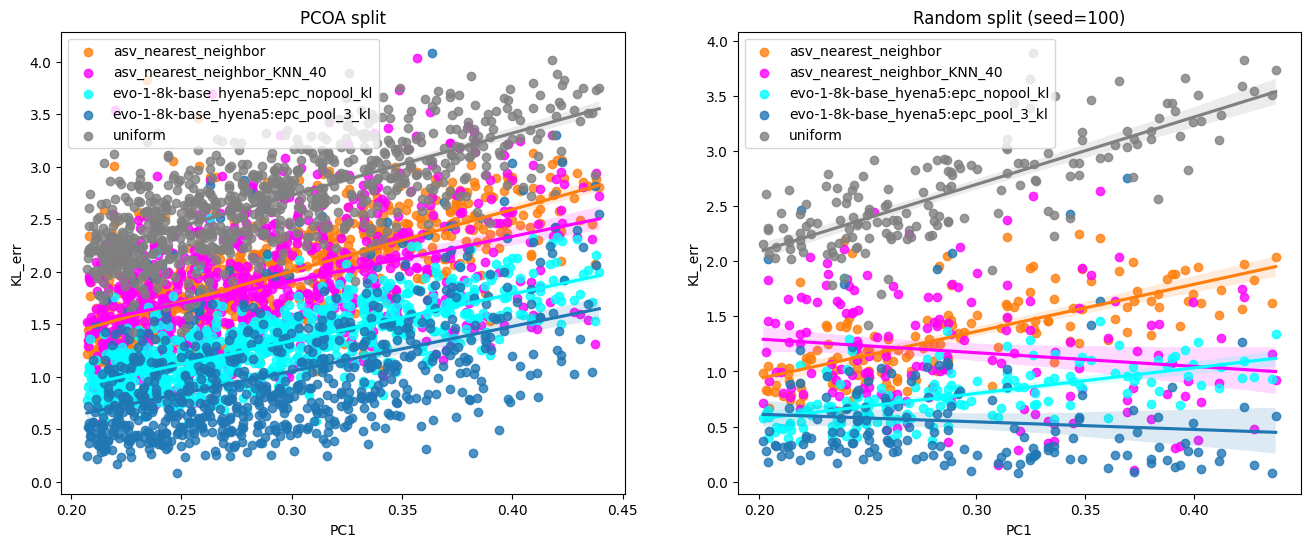

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
testplot(pcoa_result_df, axes[0])
axes[0].set_title("PCOA split")

testplot(random_split_100_result_df, axes[1])
axes[1].set_title("Random split (seed=100)")